# MACE in Practice I

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ddmms/camml-tutorials/blob/main/notebooks/07-mlips/T01_MACE_Practice_I.ipynb)

In this tutorial, you will learn how to fit and test a `MACE` model (Message Passing Neural Network), which is a highly accurate and efficient MLIP (Machine Learnning Interatomic Potential). The training/testing techniques we show here, however, are broadly applicable to all MLIPs. You can independently learn about MACE by studying the [original method paper](https://proceedings.neurips.cc/paper_files/paper/2022/file/4a36c3c51af11ed9f34615b81edb5bbc-Paper-Conference.pdf). MACE was developed by unifying the Atomic Cluster Expansion (ACE) approach with the Neural Equivariant Interatomic Potentials (NequIP). The mathematical formalism which unifies these methods is explained in the [accompaning paper](https://doi.org/10.48550/arXiv.2205.06643). Another [useful reference](https://doi.org/10.48550/arXiv.2305.14247) showcases the method's performance on published benchmark datasets. The [code implementation](https://github.com/ACEsuit/mace) is publically available and [here](https://mace-docs.readthedocs.io/en/latest/) you can find the documentation.

## Learning Objectives for today:

1. **Understanding the data: diverse configs, reference labels**
2. **Understanding MACE parameters: architecture and training**
3. **Fitting and testing MACE models**
4. **Ultimate goal: stable and accurate Molecular Dynamics**

## Setup(optional)

The next cell needs to be run only if you use google colab. Commands may work in other environments too but are not tested.

In [ ]:
# ### only if you are in google colab

# import locale
# locale.getpreferredencoding = lambda: "UTF-8"

# ! uv pip install mace-torch data-tutorials weas_widget tblite rdkit  --system
# get_ipython().kernel.do_shutdown(restart=True)

# ! pip install git+https://github.com/imagdau/aseMolec@main

Using Python 3.12.3 environment at: /usr
error: The interpreter at /usr is externally managed, and indicates the following:

  To install Python packages system-wide, try apt install
  python3-xyz, where xyz is the package you are trying to
  install.

  If you wish to install a non-Debian-packaged Python package,
  create a virtual environment using python3 -m venv path/to/venv.
  Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
  sure you have python3-full installed.

  If you wish to install a non-Debian packaged Python application,
  it may be easiest to use pipx install xyz, which will manage a
  virtual environment for you. Make sure you have pipx installed.

  See /usr/share/doc/python3.12/README.venv for more information.

hint: Virtual environments were not considered due to the `--system` flag
  Cloning https://github.com/imagdau/aseMolec (to revision main) to /tmp/pip-req-build-c66nlpql
  Running command git clone --filter=blob:none --quiet https://github.com/

: 

now grab the data needed for tutorial

In [ ]:
from data_tutorials.data import get_data

get_data(
    url="https://github.com/IsaacParker30/ccp5/data_perm/",
    filename=["cat_eth_caf_data.xyz",  "cat_eth_caf_expanded_data.xyz",  "caffeine_ethanol_scan_xtb.xyz"],
    folder="data",
)

try to download cat_eth_caf_data.xyz from https://raw.githubusercontent.com/ccp5UK/summerschool/main/Day_9ML/data_perm/ and save it in data/cat_eth_caf_data.xyz


cat_eth_caf_data.xyz: 0.00B [00:00, ?B/s]

HTTPError: HTTP Error 404: Not Found

## 1. Understanding the data

### 1.1 Diverse Molecular Conformations

Understanding the data is a crucial part of fitting an MLIP. Most models will underperform at first, often because of insufficiently representative data.
In this application, we will develop an MLIP for 2 Molecules: Caffeine (which you may will be well versed with if you are a student of science) and Ethanol (which you may will be well versed with if you are a student of life).  First let's visualise the molecules:

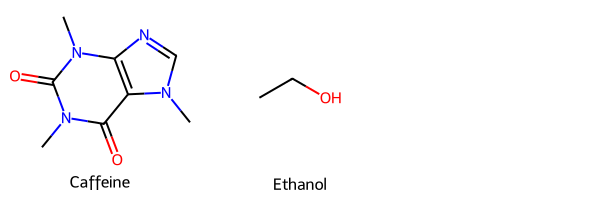

In [115]:
from rdkit import Chem
from rdkit.Chem import Draw

# choose your device here.
#device = 'cpu'
device =  'cuda'

# SMILES strings for each molecule
sm_dict = {
    'Caffeine': 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
    'Ethanol': 'CCO',
}

Draw.MolsToGridImage([Chem.MolFromSmiles(sm_dict[mol]) for mol in sm_dict], legends=list(sm_dict.keys()))

For this tutorial, we prepared in advance a collection of atomic configurations. Let's understand the data! We start by loading the raw configurations with no `labels` (energy, forces). The atomic `configurations`are stored in the [extxyz](https://wiki.fysik.dtu.dk/ase/ase/io/formatoptions.html#extxyz) format and can be accessed using [ASE](https://wiki.fysik.dtu.dk/ase/index.html) as shown below:

In [116]:
from ase.io import read, write
from weas_widget import WeasWidget

import numpy as np

db = read('data/cat_eth_caf_data.xyz', ':') #read in list of configs

print("Number of configs in database: ", len(db))
print("Number of atoms in each config: ", np.array([len(at) for at in db]))
print("Number of atoms in the smallest config: ", np.min([len(at) for at in db])) #test if database contains isolated atoms
print("Information stored in config.info: \n", db[10].info) #check info
print("Information stored in config.arrays: \n", db[10].arrays)

Number of configs in database:  1705
Number of atoms in each config:  [9 9 9 ... 9 9 9]
Number of atoms in the smallest config:  9
Information stored in config.info: 
 {'config_type': 'ethanol', 'temperature': 300.0, 'energy_xtb': -309.74730728676263}
Information stored in config.arrays: 
 {'numbers': array([6, 6, 8, 1, 1, 1, 1, 1, 1]), 'positions': array([[-0.72879989,  0.038287  ,  0.36981398],
       [ 0.44155199, -0.4209357 , -0.49127848],
       [ 1.41721219,  0.58453427, -0.58200103],
       [-1.44515926, -0.74581468,  0.50662551],
       [-1.1688501 ,  0.85113748, -0.07780264],
       [-0.32233185,  0.42021063,  1.36412983],
       [ 0.04235423, -0.55851729, -1.49784123],
       [ 0.98529636, -1.40188597, -0.23599812],
       [ 0.90059464,  1.38337037, -0.85341323]]), 'forces_xtb': array([[ 2.08728032, -1.06405255,  2.30011811],
       [ 0.46870944, -0.99147548, -0.44599334],
       [-0.4222952 ,  0.88798286, -0.12617065],
       [-0.24831206, -0.32460829,  0.25194047],
       [

'Nmol = 6 #show distribution of compositions for cluster size 6\nplt.pie(comp_dict[Nmol].values(),\n        labels=comp_dict[Nmol].keys(),\n        explode=10/(25+np.array(list(comp_dict[Nmol].values()))),\n        rotatelabels =True);'

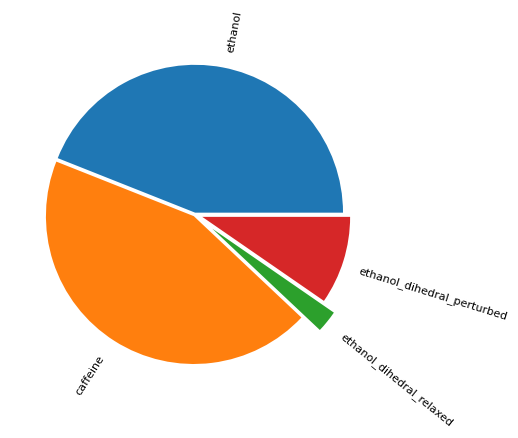

In [117]:
from aseMolec import extAtoms as ea
from collections import Counter
import matplotlib.pyplot as plt

num_confs=Counter([at.info['config_type'] for at in db]) #count number of configs for each chemical formula
plt.pie(num_confs.values(),
        labels=num_confs.keys(),
        explode=10/(25+np.array(list(num_confs.values()))),
        rotatelabels =True);
"""Nmol = 6 #show distribution of compositions for cluster size 6
plt.pie(comp_dict[Nmol].values(),
        labels=comp_dict[Nmol].keys(),
        explode=10/(25+np.array(list(comp_dict[Nmol].values()))),
        rotatelabels =True);"""

We can visualize the databse using the WEAS pyhon library, or locally we can use a standalone software like `ovito` to view the `*.xyz` files directly. You can launch the `Desktop` application for `ovito` from the `Launcher` and navigate to your working directory in the terminal, then simply run `ovito <filename>.xyz`.

In [118]:
import ipywidgets as widgets
from weas_widget import WeasWidget
from IPython.display import display, HTML


# Function to display a molecule
def display_molecule(atoms):
    viewer = WeasWidget()
    viewer.from_ase(atoms)
    display(viewer)

viewers = []
for atoms in db[:10]: #display the first 10 configurations
    viewer = WeasWidget()
    viewer.from_ase(atoms)
    viewer.avr.model_style = 0
    viewer.avr.show_hydrogen_bonds = False
    viewers.append(viewer)

left_column = widgets.VBox(viewers[::2])  # Even-indexed viewers
right_column = widgets.VBox(viewers[1::2])  # Odd-indexed viewers

display(widgets.HBox([left_column, right_column]))

At this point, each configuration is a collection of atoms: atomic number (Z) and positions (R), with no additional information. Let's identify the molecules and label molecular clusters. This will make it easier to inspect the data set and, later, test the accuracy of the potential on describing inter-molecular interactions. Molecule identification is achieved using the `wrap_molecs` function from the [aseMolec package](https://github.com/imagdau/aseMolec), shown here for the first 100 frames `db[:100]`.

In [ ]:
from aseMolec import anaAtoms as aa

aa.wrap_molecs(db[:100], prog=False) #identify molecules and label molecular clusters, showcase: first 100 frames
print("Information stored in config.info: \n", db[10].info)
print("Information stored in config.arrays: \n", db[10].arrays)

Information stored in config.info: 
 {'config_type': 'ethanol', 'temperature': 300.0, 'energy_xtb': -309.74730728676263, 'Nmols': 1, 'Comp': '---UNK_C2H6O(1)'}
Information stored in config.arrays: 
 {'numbers': array([6, 6, 8, 1, 1, 1, 1, 1, 1]), 'positions': array([[-0.72879989,  0.038287  ,  0.36981398],
       [ 0.44155199, -0.4209357 , -0.49127848],
       [ 1.41721219,  0.58453427, -0.58200103],
       [-1.44515926, -0.74581468,  0.50662551],
       [-1.1688501 ,  0.85113748, -0.07780264],
       [-0.32233185,  0.42021063,  1.36412983],
       [ 0.04235423, -0.55851729, -1.49784123],
       [ 0.98529636, -1.40188597, -0.23599812],
       [ 0.90059464,  1.38337037, -0.85341323]]), 'forces_xtb': array([[ 2.08728032, -1.06405255,  2.30011811],
       [ 0.46870944, -0.99147548, -0.44599334],
       [-0.4222952 ,  0.88798286, -0.12617065],
       [-0.24831206, -0.32460829,  0.25194047],
       [-1.13762431,  1.77992805, -1.13056348],
       [-0.58163598, -0.76186501, -0.95715028],
    

Note the additional information for each atomic config: number of molecules `Nmols`, molecular composition `Comp` (e.g `DEC(1):EC(1)` means the config comprises a dimer with 1 DEC molecule and 1 EC molecule) and molecular ID `molID`. Running the code for the full 5000 configurations can be slow, let's just load the final result (`data/solvent_molecs.xyz`) and inspect the distribution of configs by number of molecules:

**Task for you**
<div class="alert alert-block alert-info">

We have a lot of the same molecule within the training set. How can we look at the structural diversity? Plot the dihedral angles and bond lengths
</div>

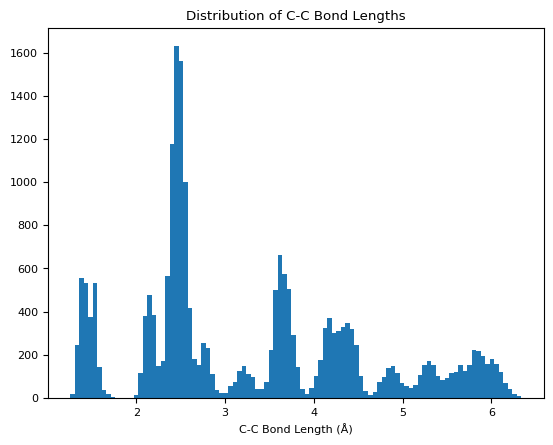

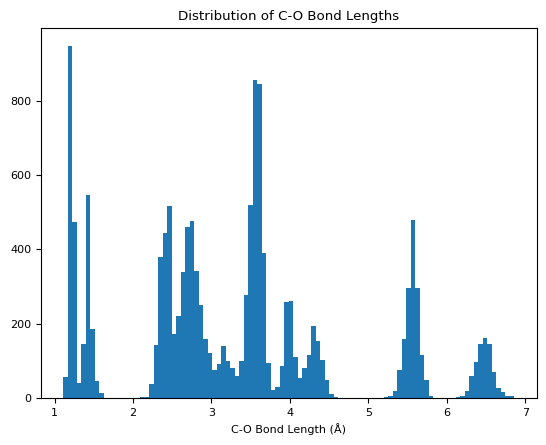

In [120]:
import matplotlib.pyplot as plt
carbon_indexes=[[i for i, at in enumerate(db[j]) if at.number == 6] for j in range(len(db))]
oxygen_indexes=[[i for i, at in enumerate(db[j]) if at.number == 8] for j in range(len(db))]
c_c_bond_lengths=[]
for j in range(len(db)):
    for i in range(len(carbon_indexes[j])):
        for k in range(i+1, len(carbon_indexes[j])):
            c_c_bond_lengths.append(db[j].get_distance(carbon_indexes[j][i], carbon_indexes[j][k]))
plt.hist(c_c_bond_lengths, bins=100)
plt.xlabel('C-C Bond Length (Å)')
plt.title('Distribution of C-C Bond Lengths')
plt.show()

c_o_bond_lengths=[]
for j in range(len(db)):
    for i in range(len(carbon_indexes[j])):
        for k in range(len(oxygen_indexes[j])):
            c_o_bond_lengths.append(db[j].get_distance(carbon_indexes[j][i], oxygen_indexes[j][k]))
plt.hist(c_o_bond_lengths, bins=100)
plt.xlabel('C-O Bond Length (Å)')
plt.title('Distribution of C-O Bond Lengths')
plt.show()

### 1.2 Labeling Data with XTB Values

We convinced ourselves the training set is quite diverse, it samples many compositions and molecular cluster sizes. It is time to prepare the reference data (energies, forces) to train the model on. We will do this using the Semiempirical Tight Binding level of theory with [XTB](https://tblite.readthedocs.io/en/latest/users/ase.html). This may be less accurate than other methods specialized for these systems, but it is fast and it will later allow us to test MLIP errors on-the-fly.

In [121]:
from ase import Atoms

db = read('/home/ijp30/ijp30/learning/ccp9/data/cat_eth_caf_data.xyz', ':')

print("Number of configs in database: ", len(db))

Number of configs in database:  1705


We are now ready to compute the energy and forces with XTB:

In [122]:
from tqdm import tqdm
from tblite.ase import TBLite
xtb_calc = TBLite(method="GFN2-xTB",verbosity=0)

for at in tqdm(db[:15]): #showcase: first 15 frames
    at.calc = xtb_calc
    at.info['energy_xtb'] = at.get_potential_energy()
    at.arrays['forces_xtb'] = at.get_forces()
# write('data/solvent_xtb.xyz', db) #save full result

print("Information stored in config.info: \n", db[13].info) #check info
print("Information stored in config.arrays: \n", db[13].arrays)

100%|██████████| 15/15 [00:00<00:00, 588.90it/s]

Information stored in config.info: 
 {'config_type': 'ethanol', 'temperature': 300.0, 'energy_xtb': -309.6818346261791}
Information stored in config.arrays: 
 {'numbers': array([6, 6, 8, 1, 1, 1, 1, 1, 1]), 'positions': array([[-0.74735068,  0.09965208,  0.48236273],
       [ 0.42449221, -0.40431323, -0.39482106],
       [ 1.43774674,  0.53479813, -0.80914233],
       [-1.33695249, -0.69945437,  0.84957935],
       [-1.38711961,  0.89023238,  0.1424932 ],
       [-0.31148325,  0.34414179,  1.4529044 ],
       [ 0.07111086, -0.90997316, -1.26628563],
       [ 1.00897793, -1.18527676,  0.18880154],
       [ 1.03952701,  1.36465363, -1.03481701]]), 'forces_xtb': array([[ 1.70969531, -0.13390385,  1.07798805],
       [ 0.85826233, -0.10879022,  0.83958723],
       [-0.51753734, -0.9305091 ,  0.80346904],
       [-0.90566971, -1.21634839, -0.65601811],
       [ 0.14160627,  0.26683118, -0.52194972],
       [ 0.31876085,  1.01938893, -0.06837305],
       [-0.53862185, -0.28372017, -0.8552217

The updated data contains one energy value for each config `energy_xtb` and the `forces_xtb` on each atom. Latest version of [ASE](https://wiki.fysik.dtu.dk/ase/index.html) does not support simple names such as `energy` and `forces` so we append `_xtb`. The entire computation takes about `25 mins` for the 5003 configs. We have precomputed the data, so we can simply load the final result. 

Notice the data set contains isolated molecules but no isolated atoms. MACE (and other MLIPs) fit to atomization energies (eV) which is total energy minus the energy of each atom in vacuum $(E^{0})$:
$$
E^{\rm atm} = E^{\rm tot}-\sum_i^{N} E^{0}
$$

In our specific example, all molecules comprise three chemical elements and we will need to compute $(E^{0})$ for each of them:

$$
E^{\rm atm} = E^{\rm tot}-\sum_i^{N_H} E^{H}_i-\sum_i^{N_C} E^{C}_i-\sum_i^{N_N} E^{N}_i-\sum_i^{N_O} E^{O}_i 
$$

Let us add three frames containing Hydrogen H, Carbon C, Nitrogren N and Oxygen O to the dataset and label them as `config_type=IsolatedAtom`

**Task for you**
<div class="alert alert-block alert-info">

Calculate the E0s of the isolated atoms. It may also help to calculate their forces. Save these as 'energy_xtb' and 'forces_xtb' to the atoms object.
</div>

In [123]:
isolated_atoms = [Atoms('H'), Atoms('C'), Atoms('N'), Atoms('O')] #add isolated atoms to the database

from tqdm import tqdm
from tblite.ase import TBLite
xtb_calc = TBLite(method="GFN2-xTB",verbosity=0)

for at in tqdm(isolated_atoms): #showcase: first 15 frames
    at.calc = xtb_calc
    at.info['energy_xtb'] = at.get_potential_energy()
    at.arrays['forces_xtb'] = at.get_forces()
    print(f"Energy for {at.get_chemical_symbols()[0]}: {at.info['energy_xtb']}")

100%|██████████| 4/4 [00:00<00:00, 1218.74it/s]

Energy for H: -10.70721125644397
Energy for C: -48.84744536025193
Energy for N: -71.00681811557804
Energy for O: -102.57117257606656


We can now add these isolated atoms to the dataset, but we need to set their ... to at.info['config_type'] = 'IsolatedAtom'

In [124]:
for at in isolated_atoms:
    at.info['config_type'] = 'IsolatedAtom'
db+=isolated_atoms
write('data/cat_eth_caf_data_E0s.xyz', db) #save full result
write('data/HCNO_E0s.xyz', isolated_atoms) #save full result

In [125]:
db = read('data/cat_eth_caf_data_E0s.xyz', ':')
config_index=13

print("E0s: \n", ea.get_E0(db, tag='_xtb'))
print(f"Total energy for config {config_index}: \n", ea.get_prop(db, 'info', 'energy_xtb', peratom=False)[config_index])
print(f"Total energy per atom for config {config_index}: \n", ea.get_prop(db, 'info', 'energy_xtb', peratom=True)[config_index])

E0s: 
 {'H': -10.70721125644397, 'C': -48.84744536025193, 'N': -71.00681811557804, 'O': -102.57117257606656}
Total energy for config 13: 
 -309.6818346261791
Total energy per atom for config 13: 
 -34.40909273624212


**Task for you**
<div class="alert alert-block alert-info">

Visualise the spread of energies and forces in the whole dataset. It's up to you how to do this but a Histrogram or Scatter Plot may be a good idea.  
</div>

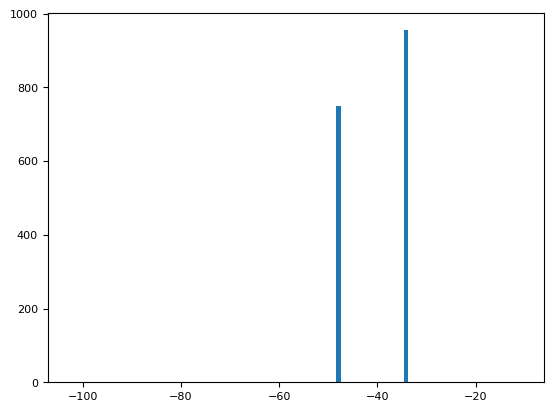

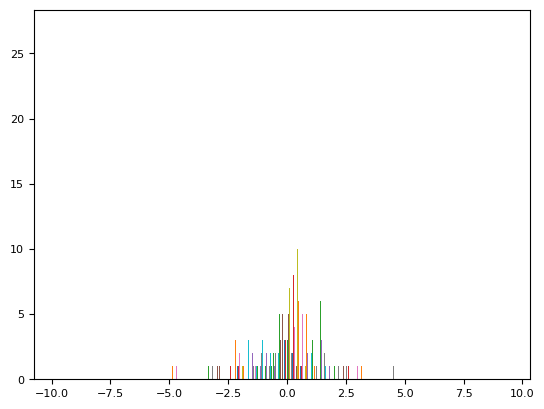

In [ ]:
energies=ea.get_prop(db, 'info', 'energy_xtb', peratom=True)
forces=ea.get_prop(db, 'arrays', 'forces_xtb', peratom=False).flatten()
plt.hist(energies, bins=100)
plt.show()
plt.hist(forces, bins=100)
plt.show()

## 2. Understanding MACE parameters

### 2.1 Model parameters

We'll give a high-level explanation of the important parameters in MACE. We will discuss these in detail during the third tutorial and associated lectures. Consult the [documentation](https://github.com/ACEsuit/mace) for additional parameters. You may wish to revisit this material later. 

- ##### <font color='red'>--r_max</font>: the cutoff radius

The cut-off applied to local environment in each layer. `r_max=4.0` means atoms separated by a distance of more than 4.0 A do not directly `communicate`. When the model has multiple message-passing layers, atoms further than 4.0 A can still `communicate` through later messages if intermediate proxy atoms exist. The effective `receptive field` of the model is `num_interactions x r_max`.

<font color='blue'>**The rest of these keywords will make more sense at a later data, so feel free to skip for now**</font>

- ##### <font color='red'>--num_interactions</font>: message-passing layers

Controls the number of message-passing layers in the model.

- ##### <font color='red'>--hidden_irreps</font>: number of messages and their symmetry

Determines the size of the model and its symmetry.
For example: `hidden_irreps='128x0e'` means the model has `128` channels or paths, the output is invariant under rotation ($L_{\rm max}=0$) and even under inversion (`'e'`). For most applications, these settings will do well. `hidden_irreps='64x0e + 64x1o'` means the model has `64` channels and is equivariant under rotation ($L_{\rm max}=1$).

Alternatively, the model size can be adjusted using a pair of more user-friendly arguments:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; <font color='red'>--num_channels=32</font>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; <font color='red'>--max_L=2</font>

which, taken together achieve the same as <font color='red'>--hidden_irreps='32x0e + 32x1o + 32x2e'</font>
    
<font color='blue'>**In general, the `accuracy` of the model can be improved by using more layers, more channels or higher equivariances. This will result in more parameters and `slower` models.**</font>

- ##### <font color='red'>--correlation</font>: the order of the many-body expansion
$$
E_{i} = E^{(0)}_{i} + \sum_{j} E_{ij}^{(1)} + \sum_{jk} E_{ijk}^{(2)} + ...
$$

The energy-expansion order that MACE induces at each layer. Choosing `--correlation=3` will create basis functions of up to 4-body (ijkl) indices, for each layer. If the model has multiple layers, the effective correlation order is higher. For example, a two-layer MACE with `--correlation=3` has an effective body order of `13`.

- ##### <font color='red'>--max_ell</font>: angular resolution

The angular resolution describes how well the model can describe angles. This is controlled by `l_max` of the spherical harmonics basis (not to be confused with `L_max`). Larger values will result in more accurate but slower models. The default is `l_max=3`, appropriate in most cases.

Let's train our first model:

In [127]:
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

Path("config/").mkdir(parents=True, exist_ok=True)


In [128]:
%%writefile config/config-01.yml

model: MACE
num_interactions: 2
num_channels: 32
max_L: 0
r_max: 4.0
max_ell: 2

Overwriting config/config-01.yml


In [129]:
!mace_run_train --config config/config-01.yml --seed 42

/home/ijp30/mace-env/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/ijp30/mace-env/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/ijp30/mace-env/lib/python3.12/site-packages/torch/jit/_script.py:1480: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
usage: mace_run_train [-h] [--config CONFIG] --name NAME [--seed SEED]
                      [--work_dir WORK_DIR] [--

This won't work, of course, we still need to supply the training data and a model name, at a minimum. In fact, let's take a look at the remaining parameters which control the file management and training protocol.

### 2.2 Training and data management parameters

Let's start by splitting the data into a train and test set.

In [ ]:
from ase.io import read, write
import numpy as np


#Load the data
db = read('data/cat_eth_caf_data.xyz', ':')
isolated_atoms= read('data/HCNO_E0s.xyz', ':')
len_data=len(db)
print(f"Number of configs in database: {len_data}")

#Set fraction of database we want to use for training, the rest will be used for validation
train_number=200
valid_number=500
print(f"Number of configs for training: {train_number}")
print(f"Number of configs for validation: {valid_number}")
if train_number+valid_number>len_data:
    raise ValueError(f"train_number + valid_number = {train_number+valid_number} exceeds the number of configs in the database: {len_data}")

#Randomly shuffle the database
np.random.seed(42)
np.random.shuffle(db)

write(f'data/cat_eth_caf_xtb_train_{train_number}.xyz', db[:train_number]+isolated_atoms) #first train_number configs
write(f'data/cat_eth_caf_xtb_validation_{valid_number}.xyz', db[-valid_number:]) #last valid_number configs for validation

Number of configs in database: 1705
Number of configs for training: 1200
Number of configs for validation: 500


In [131]:
from ase.io import read, write
from weas_widget import WeasWidget


traj = read(f'data/cat_eth_caf_xtb_train_{train_number}.xyz', ':')

viewert = WeasWidget()
viewert.from_ase(traj)
viewert.avr.model_style = 0
viewert.avr.show_hydrogen_bonds = False
viewert

WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x77e6761e64e0>,))

- ##### <font color='red'>--name</font>: the name of the model
This name will be used to form file names (model, log, checkpoints, results), so choose a distinct name for each experiment

- ##### <font color='red'>--model_dir, --log_dir, --checkpoints_dir, --results_dir</font>: directory paths
These are the directories where each type of file is saved. 
- ##### <font color='red'>--train_file</font>: name of training data

These data configs are used to compute gradients and update model parameters.

- ##### <font color='red'>--valid_file</font>: name of validation data
An alternative way to choose the validation set is by using the `--valid_fraction` keyword. These data configs are used to estimate the model accuracy during training, but not for parameter optimization. The validation set also controls the stopping of the training. At each `--eval_interval` the model is tested on the validation set. The evaluation of these configs takes place in batches, which can be controlled by `--valid_batch_size`. If the accuracy of the model stops improving on the validation set for `--patience` number of epochs, the model will undergo **early stopping**.

- ##### <font color='red'>--test_file</font>: name of testing data

This set is entirely independent and only gets evaluated at the end of the training process to estimate the model accuracy on an independent set.

- ##### <font color='red'>--E0s</font>: isolated atom energies

Controls how `E0s` should be determined. The strongly recommended approach is to add these values to the training set with `config_type=IsolatedAtom` in `atoms.info` and set `E0s="isolated"`. If these values are not available, MACE can estimate them by least square regression over the available data `E0s="average"` which can lead to unintended consequences depending on how representative the data is.

- ##### <font color='red'>--energy_key, --forces_key</font> the key where these values are stores
This key must coincide with the `ase.Atoms.info[key]/ase.Atoms.arrays[key]` where the energies and forces are stored in the ase.Atoms object.

- ##### <font color='red'>--device</font> computing device to use
Can be CPU (`cpu`), GPU (`cuda`) or Apple Silicon (`mps`). Here we will use `cuda` since the GPU will be significantly faster than the CPU.

- ##### <font color='red'>--batch_size</font> number of configs evaluated in one batch
Number of configs used to compute the gradients for each full update of the network parameters. This training strategy is called stochastic gradient descent because only a subset of the data (`batch_size`) is used to change the parameters at each update.

- ##### <font color='red'>--max_num_epochs</font> number of passes through the data
An `epoch` is completed when the entire training data has been used once in updating the weights `batch` by `batch`. A new epoch begins, and the process repeats.

- ##### <font color='red'>--swa</font> protocol for loss weights
During training you will notice energy errors are at first much higher than force errors, MACE implements a special protocol that increases the weight on the energy in the loss function (`--swa_energy_weight`) once the forces are sufficiently accurate. The starting epoch for this special protocol can be controlled by changing `--start_swa`.

- ##### <font color='red'>--seed</font> random number generator seed
Useful for preparing committee of models.

Now we are ready to fit our first MACE model:

## 3. Fitting and Testing MACE models

### 3.1 Fitting the model

**Task for you**
<div class="alert alert-block alert-info">

We are now going to train a MACE model. Set the following keywords:
* A radial cutoff of 4
* The train and validation data are the ones we set above
* Reads the correct energy and force keys
* A batch size of 10
* Trains for 50 epochs
</div>

In [ ]:
import yaml
from pathlib import Path
model_name = f"mace01_{train_number}_{valid_number}"

config = {
    "model": "MACE",
    "num_interactions": 2,
    "num_channels": 32,
    "max_L": 0,
    "correlation": 2,
    "r_max": 4.0,
    "max_ell": 2,
    "name": model_name,
    "model_dir": f"MACE_models/{model_name}",
    "log_dir": f"MACE_models/{model_name}/logs",
    "checkpoints_dir": f"MACE_models/{model_name}/checkpoints",
    "results_dir": f"MACE_models/{model_name}/results",
    "train_file": f"data/cat_eth_caf_xtb_train_{train_number}.xyz",
    "valid_file": f"data/cat_eth_caf_xtb_validation_{valid_number}.xyz",
    "test_file": f"data/cat_eth_caf_xtb_validation_{valid_number}.xyz",
    "energy_key": "energy_xtb",
    "forces_key": "forces_xtb",
    "batch_size": 10,
    "max_num_epochs": 100,
    "swa": True,
    "swa_lr": 0.001,
    "seed": 123,
}

Path("config/config-02.yml").write_text(yaml.safe_dump(config, sort_keys=False))


583

In [135]:
dev = f'device: {device}'
%store dev >>"config/config-02.yml"

Writing 'dev' (str) to file 'config/config-02.yml'.


In [136]:

!mace_run_train --config config/config-02.yml
# if you run on cpu pass --device=cpu to the command above

#remove checkpoints since they may cause errors on retraining a model with the same name but a different architecture

p = Path("MACE_models/")

_ = [file.unlink() for file in p.glob("*_run-*.model")]
_ = [file.unlink() for file in p.glob("*.pt")]


/home/ijp30/mace-env/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/ijp30/mace-env/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/ijp30/mace-env/lib/python3.12/site-packages/torch/jit/_script.py:1480: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
2026-07-24 14:56:01.938 INFO: ===========VERIFYING SETTINGS===========
2026-07-24 14:56:01.938 INFO: MACE version: 0.3

As training is going on, we generate a number of files:

- **checkpoints** : This saves the checkpoint of the model with the lowest validation loss in each phase of training. This allows us to restart training from the latest checkpoint if something goes bad.

- **logs/{name}_run={seed}.log** : This contains the training log you see above, which contains lots of useful information about how our training/model was initialised and how things are proceeding. *This is the most important file to monitor*.
- **logs/{name}_run={seed}_debug.log** : This is the same as the log file but contains a bit more information to help you identify what happened under the hood during training and where things might have gone wrong.
- **results/{name}_run={seed}_train.txt** : This contains a breakdown of the loss and time/step at each batch during training, as well as an error breakdown once each epoch finishes. The results folder also contains schematics of the whole training process once training has ended.

**Tasks for you**
<div class="alert alert-block alert-info">

Whilst training is going on look at the training log and find the following information: 

* Have the expected number of train and validation configurations loaded? 
* Have they loaded all the energy and force keys? 
* Are the model hyperparamters (r_cut, channels, ...) as you specified?
* Are the correct E0s loaded? 
* What are the weights used in each stage of the loss?
* What is the loss on each config_type subset?
* How long did one epoch take?
* How many Epochs were in each stage?
* Which epochs have the lowest loss - are these the same as the checkpoints that were saved?

Don't worry about understanding every line in the log for now, but you make sure your training is going as you expected it to based on the hyperparameters you specified.

Look at the debug log and results file. What information can you extract from these files? 
</div>

MACE will automatically plot the loss function, energy and force errors before and after the SWA. Let's investigate below. The correlation plots correspond to the model indicated by a solid vertical line. Begining of the SWA is indicated by the dashed line.

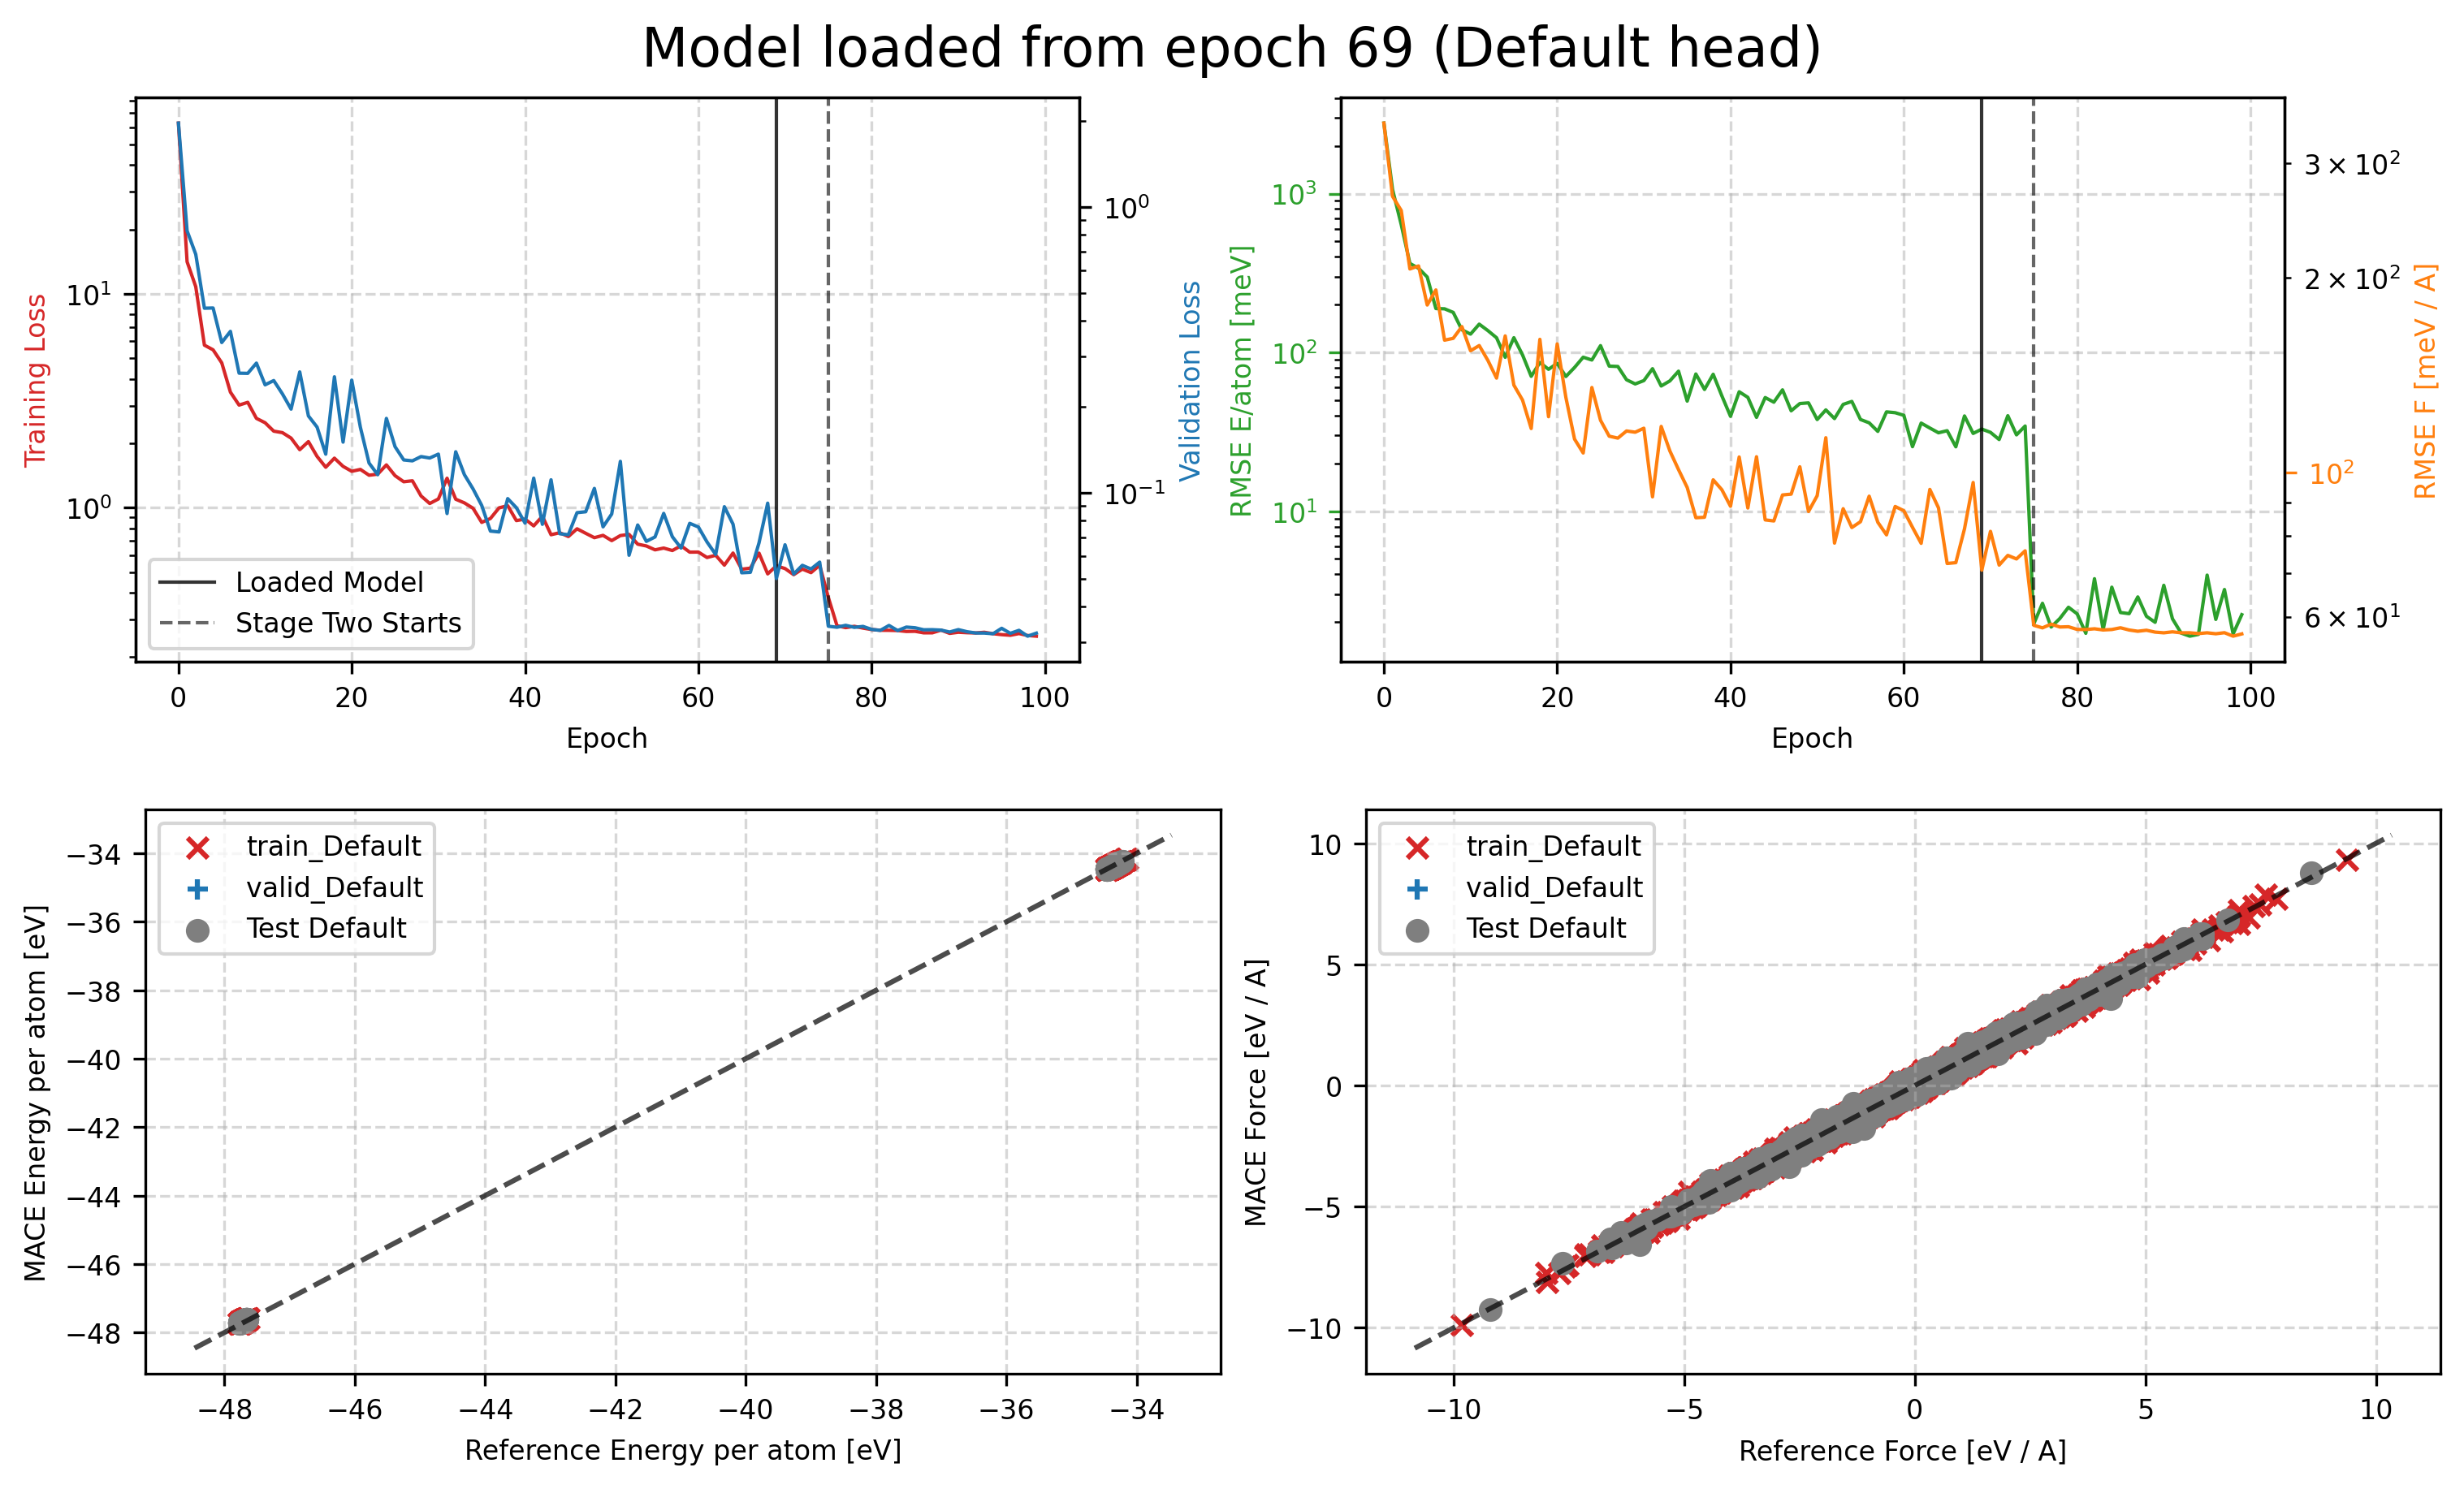

In [139]:
from IPython.display import Image, display
display(Image(f"MACE_models/{model_name}/results/mace01_{train_number}_{valid_number}_run-123_train_Default_stage_one.png"))

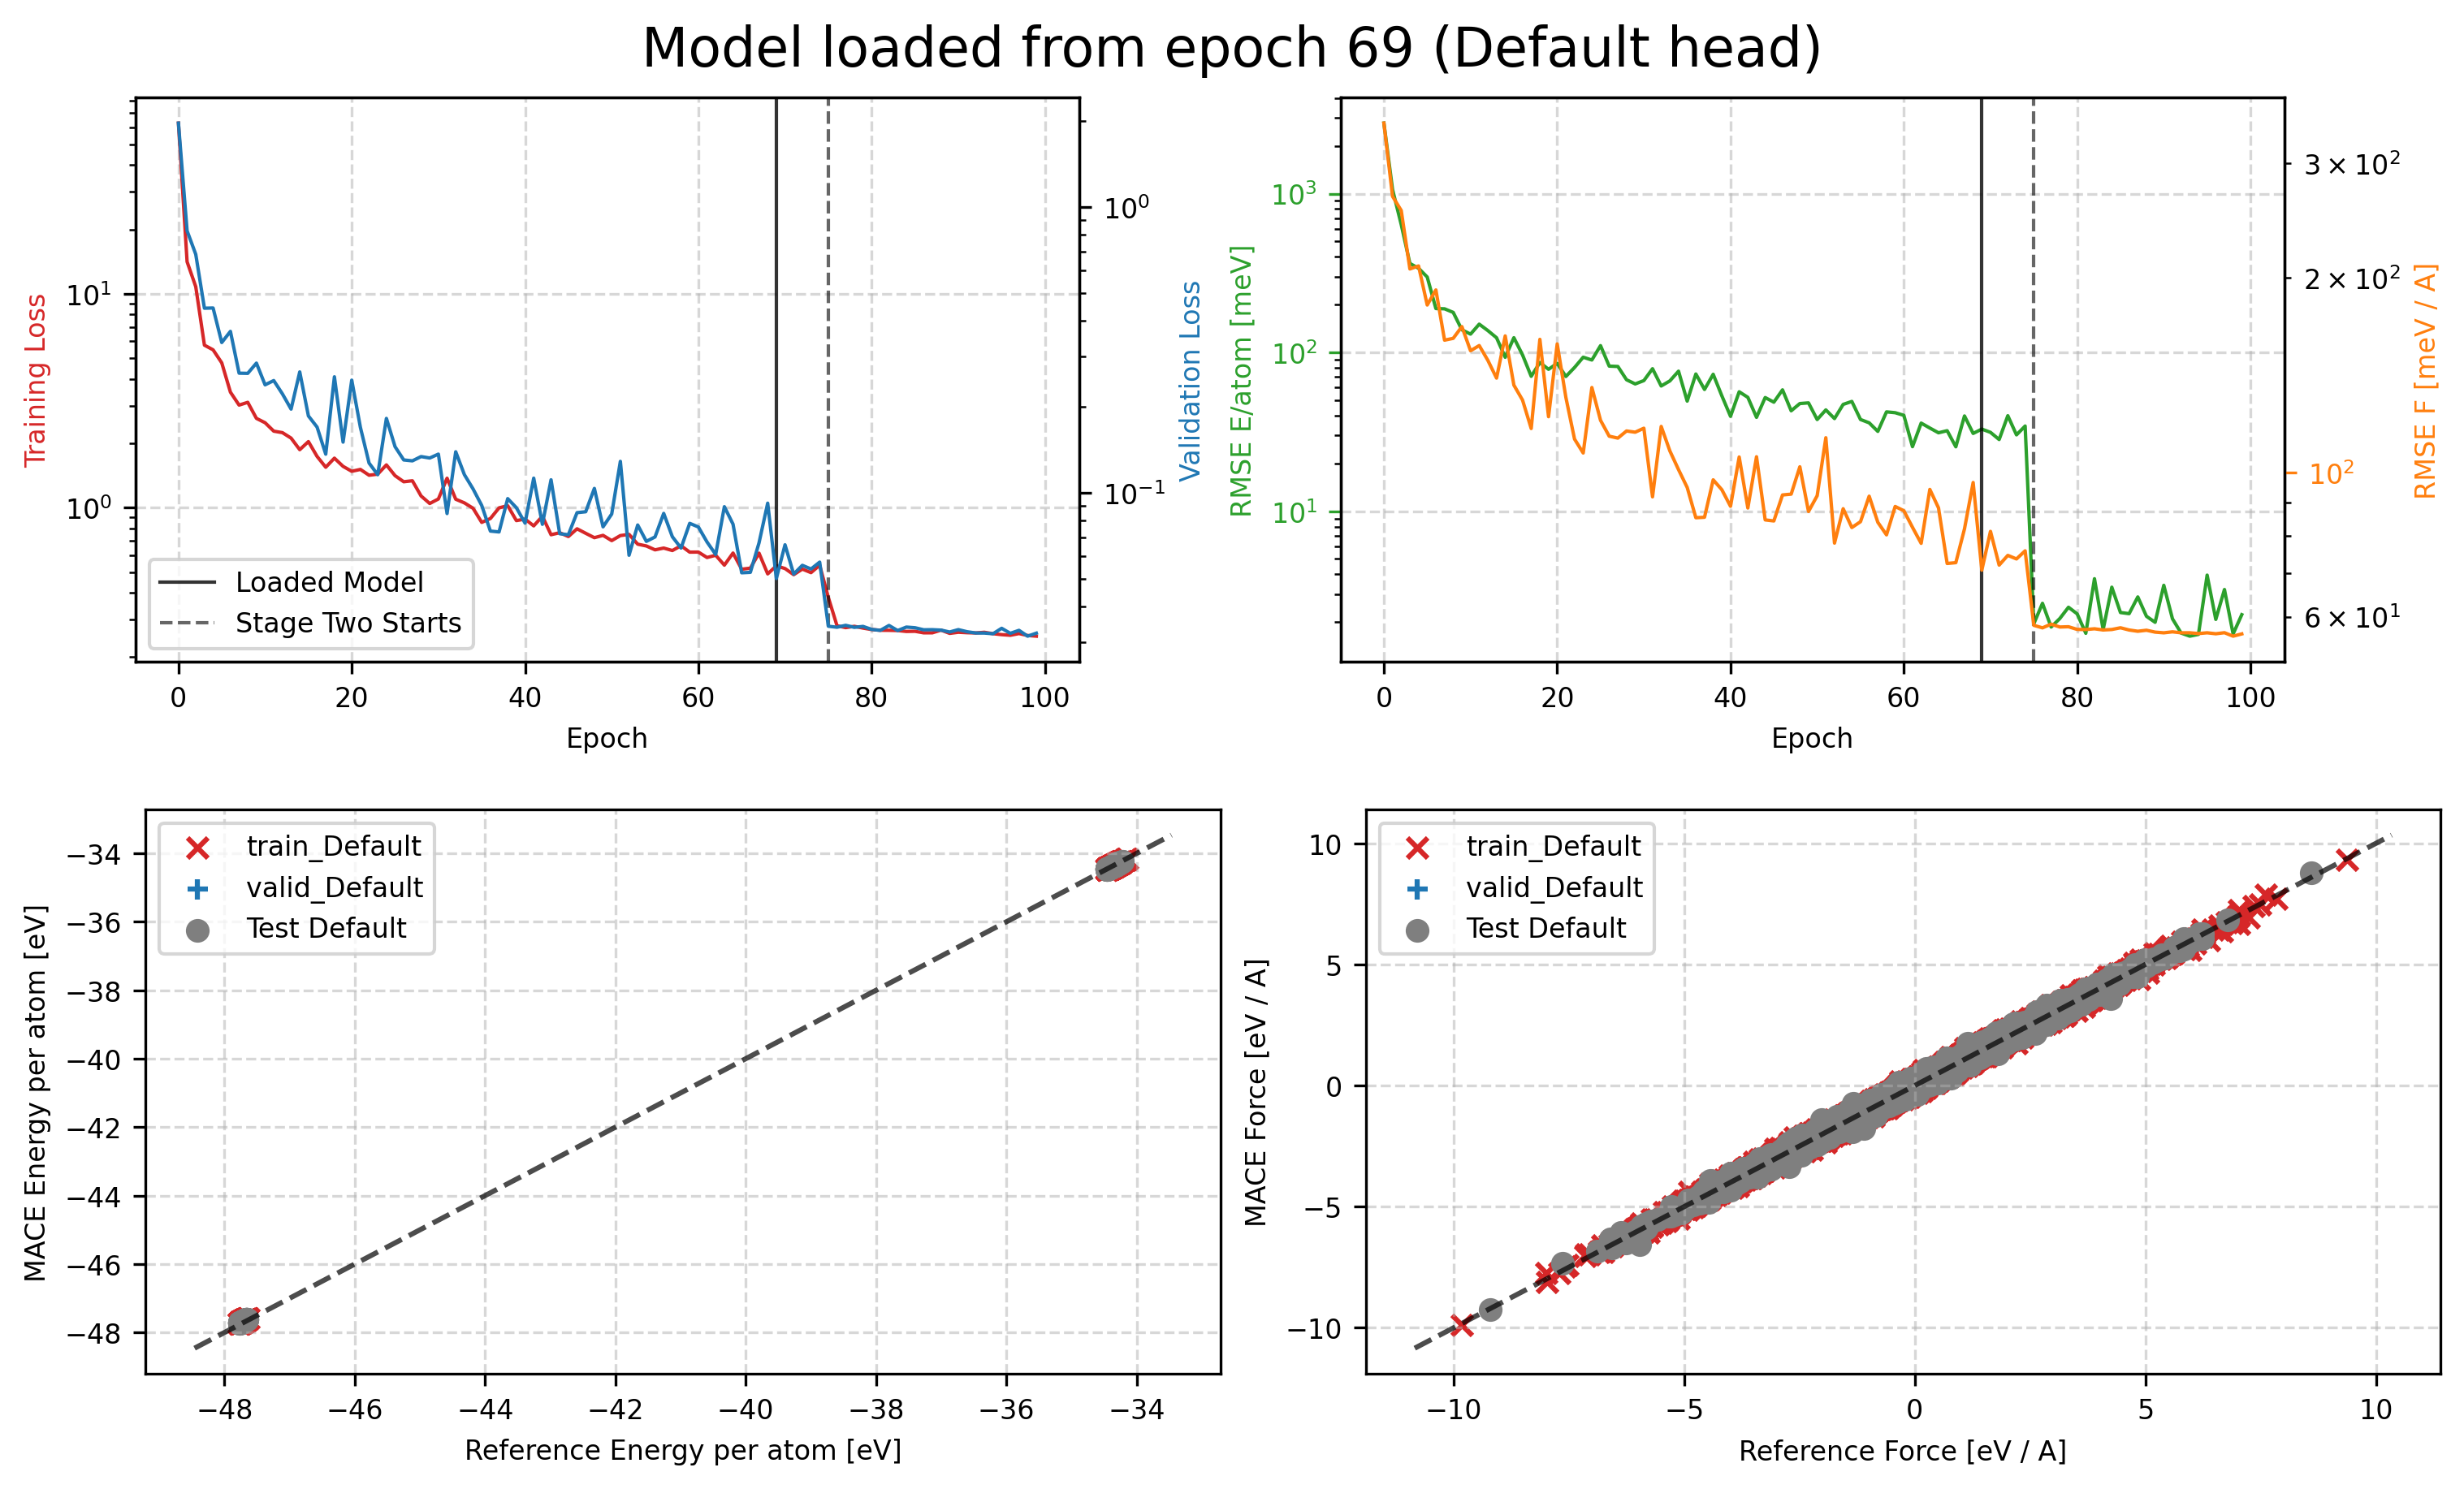

In [140]:
from IPython.display import Image, display
display(Image(f"MACE_models/{model_name}/results/mace01_{train_number}_{valid_number}_run-123_train_Default_stage_one.png"))

We will now use the `mace_eval_configs` script to evaluate the trained model on both the train and test datasets. The script takes the arguments: `--configs` which specifies the file to evaluate, the path to the model in `--model` and the path to the output in `--output`.

### 3.2 Testing the model: simple RMSEs

In [ ]:
import warnings
warnings.filterwarnings("ignore")

Path("tests/mace01/").mkdir(parents=True, exist_ok=True)


#evaluate the train set
!mace_eval_configs \
    --configs="data/cat_eth_caf_xtb_train_200.xyz" \
    --model="MACE_models/mace01_stagetwo_compiled.model" \
    --output="tests/mace01/cat_eth_caf_train_eval.xyz"

#evaluate the test set
!mace_eval_configs \
    --configs="data/cat_eth_caf_xtb_validation_500.xyz" \
    --model="MACE_models/mace01_stagetwo_compiled.model" \
    --output="tests/mace01/cat_eth_caf_validation_eval.xyz"

/home/ijp30/mace-env/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/ijp30/mace-env/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/ijp30/mace-env/lib/python3.12/site-packages/torch/jit/_script.py:1480: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/home/ijp30/mace-env/lib/python3.12/site-packages/mace/cli/eval_configs.py:140: UserWarning: Environment variable TORC

We can compare MACE vs XTB accuracy on the train and test sets and for this we will use the [aseMolec](git@github.com:imagdau/aseMolec.git) which implements some handy utilities for manipulating ase.Atoms and testing potentials, especially for molecular systems.

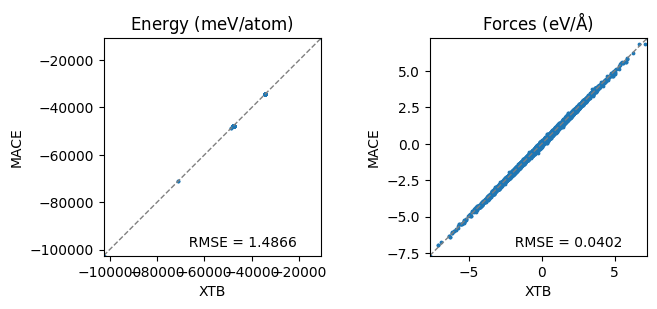

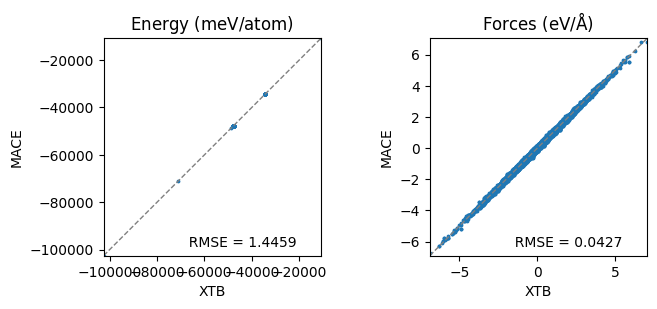

In [51]:
from aseMolec import pltProps as pp
from ase.io import read
import matplotlib.pyplot as plt
from aseMolec import extAtoms as ea
import numpy as np

def plot_RMSEs(db, labs):
    ea.rename_prop_tag(db, 'MACE_energy', 'energy_mace') #Backward compatibility
    ea.rename_prop_tag(db, 'MACE_forces', 'forces_mace') #Backward compatibility

    plt.figure(figsize=(9,6), dpi=100)
    plt.subplot(1,3,2)
    pp.plot_prop(1000*ea.get_prop(db, 'info', 'energy_xtb', True).flatten(), \
                 1000*ea.get_prop(db, 'info', 'energy_mace', True).flatten(), \
                 title=r'Energy $(\rm meV/atom)$ ', labs=labs, rel=False)
    plt.subplot(1,3,3)
    pp.plot_prop(np.concatenate(ea.get_prop(db, 'arrays', 'forces_xtb')).flatten(), \
                 np.concatenate(ea.get_prop(db, 'arrays', 'forces_mace')).flatten(), \
                 title=r'Forces $\rm (eV/\AA)$ ', labs=labs, rel=False)
    plt.tight_layout()
    return

train_data = read('tests/mace01/cat_eth_caf_train_eval.xyz', ':')
test_data = train_data[:3]+read('tests/mace01/cat_eth_caf_validation_eval.xyz', ':') #append the E0s for computing atomization energy errors

plot_RMSEs(train_data, labs=['XTB', 'MACE'])
plot_RMSEs(test_data, labs=['XTB', 'MACE'])

These figures show correlation plots between XTB values and MACE predicted values for atomization energy per atom, the total energy per atom and forces. Do the RMSE values match the number printed at the end of the model training? These errors don't look too bad, and this MACE is a small model with few parameters.

**Tasks for you**


<div class="alert alert-block alert-info">

- Are there any configurations that stand out on these parity plots - it may be of interest to look at them and see if they stand out from the rest of the dataset?

- Here we trained on a very small subset of the data, repeat training for 500, 1000, 2000, data points. How does the learning curve (test error vs size of training test) look like? - Significantly better accuracies can be achieved when training on larger models with more data. How does your model trained on more configs compare?

- You could also try increasing or decreasing the number of epochs the model trains for? How big an effect does this have? What are the potential drawbacks of training for longer?
</div>


## 4. Molecular Dynamics with MACE

### 4.1 Is the dynamics stable?

Accuracy on fixed test sets is great, but molecular dynamics (MD) is the ultimate test, check out [this paper](https://arxiv.org/abs/2409.05590) for a more detail discussion. First, we care about stability, then accuracy: let's check if MACE gives stable dynamics. We will start by implementing a simple function to run Langevin dynamics. We initialize the temperature at 300 K and remove all translations and rotations.

In [212]:
from ase.io import read, write
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import Stationary, ZeroRotation, MaxwellBoltzmannDistribution

import random
import time
import numpy as np
import pylab as pl
from IPython import display
from pathlib import Path
from weas_widget import WeasWidget

def simpleMD(init_conf, temp, calc, fname, s, T,
             friction=0.1, seed=701, set_temperature=True):
    init_conf.set_calculator(calc)

    #initialize the temperature
    random.seed(seed) #just making sure the MD failure is reproducible

    if set_temperature:
        MaxwellBoltzmannDistribution(init_conf, temperature_K=temp) #initialize temperature at 300
        Stationary(init_conf)
        ZeroRotation(init_conf)

    dyn = Langevin(init_conf, 1.0*units.fs, temperature_K=temp, friction=friction) #drive system to desired temperature

    %matplotlib inline

    time_fs = []
    temperature = []
    energies = []

    #remove previously stored trajectory with the same name
    Path(fname).unlink(missing_ok=True)

    fig, ax = pl.subplots(2, 1, figsize=(6,6), sharex='all', gridspec_kw={'hspace': 0, 'wspace': 0})

    def write_frame():
            dyn.atoms.info['md_energy'] = dyn.atoms.get_potential_energy()
            dyn.atoms.write(fname, append=True)
            time_fs.append(dyn.get_time()/units.fs)
            temperature.append(dyn.atoms.get_temperature())
            energies.append(dyn.atoms.get_potential_energy()/len(dyn.atoms))
            

            ax[0].plot(np.array(time_fs), np.array(energies), color="b")
            ax[0].set_ylabel('E (eV/atom)')

            # plot the temperature of the system as subplots
            ax[1].plot(np.array(time_fs), temperature, color="r")
            ax[1].set_ylabel('T (K)')
            ax[1].set_xlabel('Time (fs)')

            display.clear_output(wait=True)
            display.display(pl.gcf())
            time.sleep(0.01)

    dyn.attach(write_frame, interval=s)
    t0 = time.time()
    dyn.run(T)
    t1 = time.time()
    print("MD finished in {0:.2f} minutes!".format((t1-t0)/60))

Now we can run MD with MACE and compare it to the XTB dynamics. Let's try 2 picoseoncds at 1200 K, starting from a single molecule config:

In [ ]:
 #let us start with a single molecule
ethanol_index=0     #Switch to this if you want to run MD on ethanol
caffeine_index=1000
init_conf = read('data/cat_eth_caf_data.xyz', caffeine_index)

Path(f"moldyn/{model_name}/").mkdir(exist_ok=True)
print("Initial configuration: \n", init_conf)

Initial configuration: 
 Atoms(symbols='CNCNC3ONCONC2H10', pbc=False, cell=[20.0, 20.0, 20.0], forces_xtb=...)


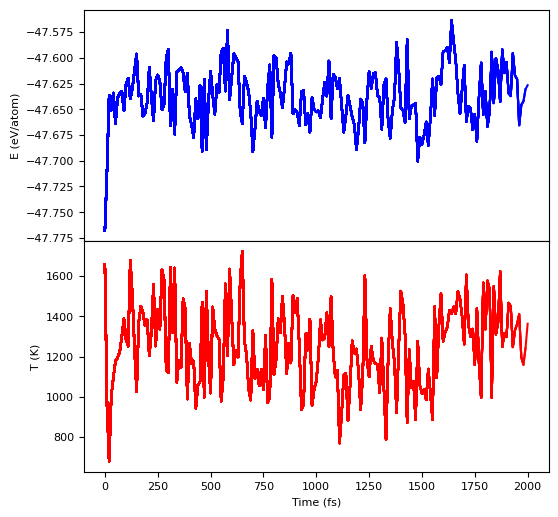

MD finished in 0.91 minutes!


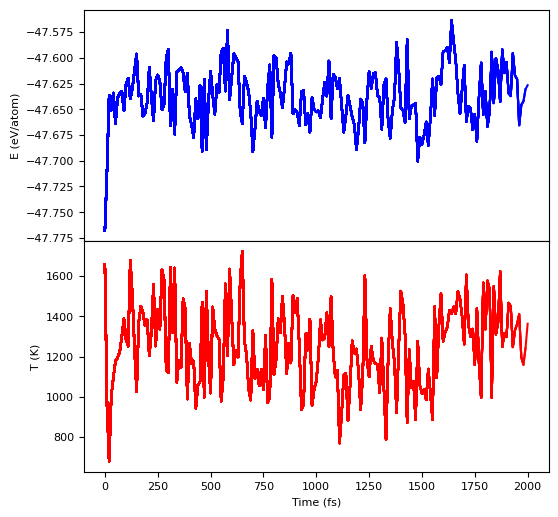

In [154]:
#we can use MACE as a calculator in ASE!
from mace.calculators import MACECalculator
# change to device='cpu' if you run on cpu
device='cuda'
md_conf=init_conf.copy()


mace_calc = MACECalculator(model_paths=[f'MACE_models/{model_name}/{model_name}_stagetwo_compiled.model'], 
                           device=device, 
                           default_dtype="float32")

simpleMD(md_conf, temp=1200, calc=mace_calc, 
         fname=f'moldyn/{model_name}/mace_md_caffeine.xyz', 
         s=10, T=2000)


In [150]:
traj = read(f'moldyn/{model_name}/mace_md_caffeine.xyz', ':')
viewer1 = WeasWidget()
viewer1.from_ase(traj)
viewer1.avr.model_style = 0
viewer1.avr.show_hydrogen_bonds = False
viewer1

WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x77e61f390680>,))

We can now evaluate this trajectory using XTB to see check models performance. We will subsample a few frames

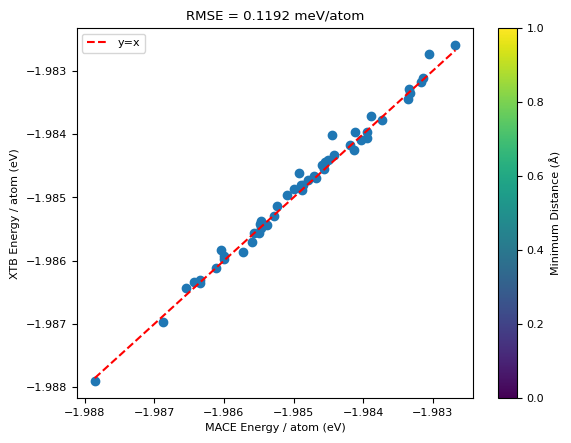

In [158]:
from ase.io import read, write
from aseMolec import extAtoms as ea
import matplotlib.pyplot as plt


sampled_mace_traj = read(f'moldyn/{model_name}/mace_md_caffeine.xyz', '1::4')
Natoms=len(sampled_mace_traj[0])
xtb_calc = TBLite(method="GFN2-xTB",verbosity=0)

for at in sampled_mace_traj:
    at.calc = xtb_calc
    at.info['energy_xtb'] = at.get_potential_energy()
    at.arrays['forces_xtb'] = at.get_forces()

mace_energies = ea.get_prop(sampled_mace_traj, 'info', 'md_energy', True).flatten()/len(sampled_mace_traj[0])
xtb_energies = ea.get_prop(sampled_mace_traj, 'info', 'energy_xtb', True).flatten()/len(sampled_mace_traj[0])

RMSE_energy = np.sqrt(np.mean((mace_energies-xtb_energies)**2))

plt.scatter(mace_energies, xtb_energies)
plt.xlabel('MACE Energy / atom (eV)')
plt.ylabel('XTB Energy / atom (eV)')
plt.plot([min(mace_energies), max(mace_energies)], [min(mace_energies), max(mace_energies)], 'r--', label='y=x')
cbar = plt.colorbar()
cbar.set_label('Minimum Distance (Å)')
plt.title(f'RMSE = {1000*RMSE_energy:.4f} meV/atom')
plt.legend()
plt.show()

You should see there is decent agreement between MACE and XTB.

**Tasks for you**


<div class="alert alert-block alert-info">
Repeat this analysis for the forces
</div>

For reference, we can also run XTB dynamics from the same starting configuration.

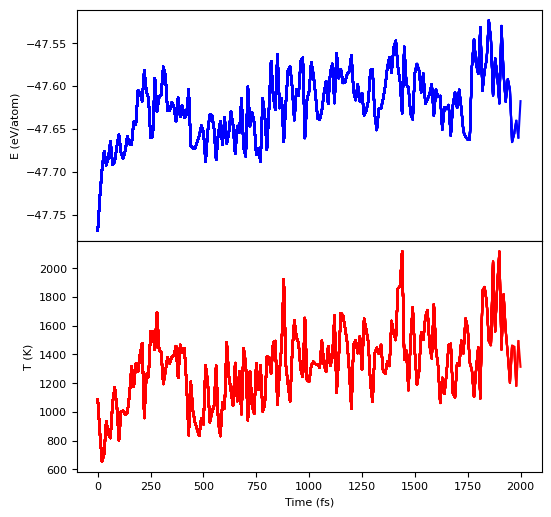

MD finished in 0.68 minutes!


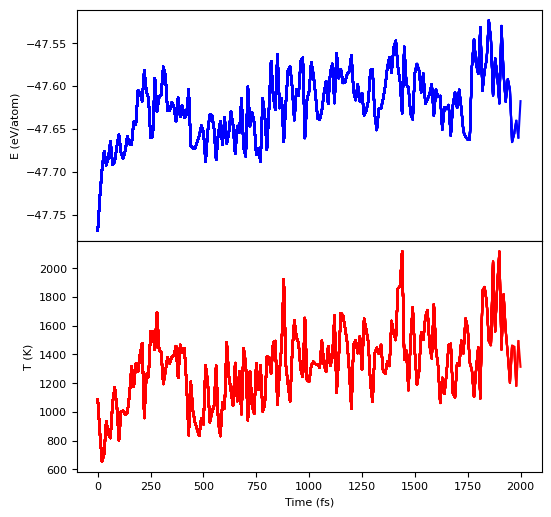

In [157]:
Path(f"moldyn/xtb/").mkdir(exist_ok=True)
md_conf=init_conf.copy()


from tblite.ase import TBLite
xtb_calc = TBLite(method="GFN2-xTB",verbosity=0)

### running this can take a long time, try for yourself. we will provide the pregenerated trajectory
simpleMD(md_conf, temp=1200, calc=xtb_calc, fname=f'moldyn/xtb/xtb_md_caffeine.xyz', s=10, T=2000)

You may find for this system MACE and XTB took a similar amount of time to run. Depending on the cost of the reference calculation however, it can be many orders of magnitude for expensive Quantum Chemistry methods and large systems. Remember, the cost of MLIP is independent of the accuracy of the potential energy surface! You may also try increasing the size of the systems and see if this still holds?

Let's visualize the trajectory:

In [159]:
from ase.io import read, write

traj = read('moldyn/xtb/xtb_md_caffeine.xyz', ':')

viewert = WeasWidget()
viewert.from_ase(traj)
viewert.avr.model_style = 0
viewert.avr.show_hydrogen_bonds = False
viewert

WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x77e61d95a210>,))

Remember, you can visualize the trajectory files `.xyz` with `ovito` in the `Desktop` opened through the `Launcher`.

Obtaining stable dynamics with so little training is a great result. Up until recently, most MLIPs would require a lot of training before MD was stable. MACE combines the lessons learned over 10-15 years in MLIP development, to achieve a smooth and regular potential energy surface, which minimizes the risk of unstable MD.

### 4.2 Is the dynamics accurate?

Are the different dynamics sampling the correct distributions? Let us check the radial distribution functions (RDF). The [aseMolec](https://github.com/imagdau/aseMolec) package provides functionality to do that:

In [3]:
from matplotlib import pyplot as plt
from aseMolec import anaAtoms as aa

tag = 'CN_inter' #example inputs: 'HH_intra', 'HC_intra', 'CO_intra', 'CC_inter

for f in ['xtb/xtb_md_caffeine.xyz', 
          f'{model_name}/mace_md_caffeine.xyz']:
    traj = read(f'moldyn/{f}', '50:') #ignore first 50 frames
    for at in traj:
        at.pbc = True #create a fake box for rdf compatibility
        at.cell = [100,100,100]
    rdf = aa.compute_rdfs_traj_avg(traj, rmax=5, nbins=50) #aseMolec provides functionality to compute RDFs
    plt.plot(rdf[1], rdf[0][tag], '.-', label=f, alpha=0.7, linewidth=3)

plt.legend();
plt.yticks([]);
plt.xlabel(r'R ($\rm \AA$)');
plt.ylabel('RDF '+tag);

NameError: name 'model_name' is not defined

***We can also try plotting the Vibrational Density of States, which gives us an idea of what the molecular spectra should look like:***

The trajectories here are stable and also quite accurate. This is still a relatively simple task: we chose a single molecule at relatively small temperatures (for a molecule) and only ran for 2 picoseconds. In practice, given enough time and high enough temperature the initial models will fail.


**Task for you**

<div class="alert alert-block alert-info">

- Try it yourself! Inspect other RDF pairs (`C-O`, `C-H`, `C-N`), how well are they reproduced?
- Experiment with the starting configs, temperatures, simulation length, see if you can find problems with the potentials!
- Try repeating for ethanol. 
</div>


### 4.3 MD of both molecules together

Up to now we have trained on each molecule in isolation, and ran MD on each molecule in isolation. What happens if we bring caffeine and ethanol together (you may already have some experience of this)? Will MACE be able to deal with it? We will initialise the velocities so the molecules come together at the beginning of the MD run

In [ ]:
from mace.calculators import MACECalculator
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
# change to device='cpu' if you run on cpu
device='cuda'
temperature=1200

init_conf = read('data/caffeine_ethanol_scan_xtb.xyz', 0) 

#Initialise with vel that move molecules towards each other
ethanol_pos=init_conf.positions[-9:]
ethanol_masses=init_conf.get_masses()[-9:]
ethanol_center=ethanol_pos.mean(axis=0)

caffeine_pos=init_conf.positions[:-9]
caffeine_masses=init_conf.get_masses()[:-9]
caffeine_center=caffeine_pos.mean(axis=0)

MaxwellBoltzmannDistribution(init_conf, temperature_K=temperature) #initialize temperature at 300

#Initialize velocities to move the molecules towards each other
delta = caffeine_center-ethanol_center
ethanol_velocities = delta  # Scale the velocity for a gentle approach
caffeine_velocities = -delta  # Opposite direction for caffeine


init_conf.arrays['momenta'][:-9] = caffeine_velocities * caffeine_masses[:, np.newaxis] 
init_conf.arrays['momenta'][-9:] = ethanol_velocities * ethanol_masses[:, np.newaxis]

#Scale velocities to match the desired temperature
current_temperature = init_conf.get_temperature()
scaling_factor = np.sqrt(temperature / current_temperature)
init_conf.arrays['momenta'] *= scaling_factor


print("Initial configuration: \n", init_conf)
#get temperature of the system
print("Initial temperature: \n", init_conf.get_temperature())


Initial configuration: 
 Atoms(symbols='CNCNC3ONCONC2H10C2OH6', pbc=False, cell=[20.0, 20.0, 20.0], forces_xtb=..., molID=..., momenta=...)
Initial temperature: 
 1200.0


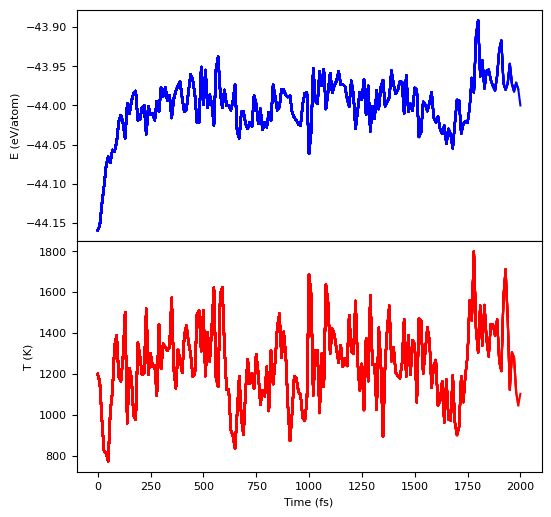

MD finished in 0.95 minutes!


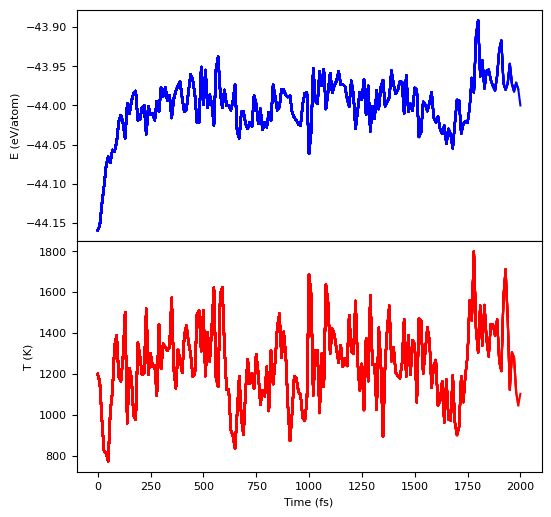

In [172]:
### running this can take a long time, try for yourself. we will provide the pregenerated trajectory
md_config=init_conf.copy()
mace_calc = MACECalculator(model_paths=[f'MACE_models/{model_name}/{model_name}_stagetwo_compiled.model'], 
                           device=device, 
                           default_dtype="float32")

simpleMD(md_config, temp=temperature, calc=mace_calc, 
         fname=f'moldyn/{model_name}/mace_md_both.xyz', s=10, T=2000,
         friction=0.1, seed=701, set_temperature=False)

In [173]:
from ase.io import read, write
from weas_widget import WeasWidget

traj = read(f'moldyn/{model_name}/mace_md_both.xyz', ':')

viewert = WeasWidget()
viewert.from_ase(traj)
viewert.avr.model_style = 0
viewert.avr.show_hydrogen_bonds = False
viewert

WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x77e6ec483440>,))

We can again compare the energies versus xtb

100%|██████████| 50/50 [00:02<00:00, 20.61it/s]

Error calculating energy and forces for configuration 45: SCF not converged in 250 cycles


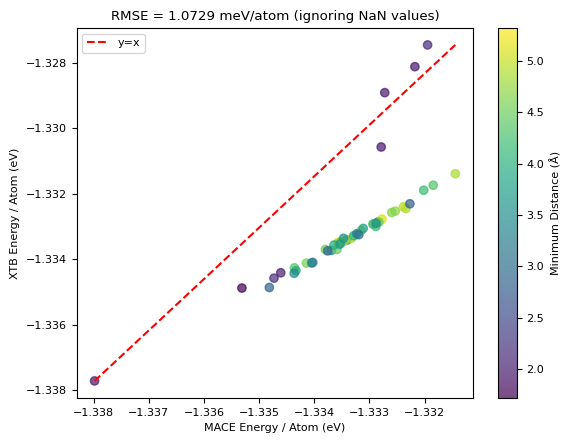

In [ ]:
from ase.io import read, write
from aseMolec import extAtoms as ea
import matplotlib.pyplot as plt
from tqdm import tqdm

sampled_mace_traj = read(f'moldyn/{model_name}/mace_md_both.xyz', '1::4')
xtb_calc = TBLite(method="GFN2-xTB",verbosity=0)


min_distances=[]

Natoms=len(sampled_mace_traj[0])
idx=0
for at in tqdm(sampled_mace_traj):
    min_distance=1000
    at.calc = xtb_calc
    try:
        at.info['energy_xtb'] = at.get_potential_energy()
        at.arrays['forces_xtb'] = at.get_forces()
    except Exception as e:
        print(f"Error calculating energy and forces for configuration {idx}: {e}")
        at.info['energy_xtb'] = np.nan
        at.arrays['forces_xtb'] = np.full_like(at.positions, np.nan)
    ethanol_positions=at.positions[-9:]
    ethanol_center=ethanol_positions.mean(axis=0)

    #We will color by min distance between atoms between 2 molecules
    #Is there any correlation?
    for pos in ethanol_positions:
        delta_eth_caff = pos - at.positions[:-9]
        distances = np.linalg.norm(delta_eth_caff, axis=1)
        min_distance = np.min([np.min(distances),min_distance])
    min_distances.append(min_distance)
    idx+=1

mace_energies = ea.get_prop(sampled_mace_traj, 'info', 'md_energy', True).flatten()
xtb_energies = ea.get_prop(sampled_mace_traj, 'info', 'energy_xtb', True).flatten()
#calculate RMSE for energies, ingnoring NaN values
valid_indices = ~np.isnan(xtb_energies)
rmse_energy = np.sqrt(np.mean((mace_energies[valid_indices]-xtb_energies[valid_indices])**2))

plt.scatter(mace_energies  / Natoms, xtb_energies  / Natoms, c=min_distances, cmap='viridis', alpha=0.7)
plt.xlabel('MACE Energy / Atom (eV)')
plt.ylabel('XTB Energy / Atom (eV)')
plt.plot([min(mace_energies / Natoms), max(mace_energies / Natoms)], 
          [min(xtb_energies / Natoms), max(xtb_energies / Natoms)], 'r--', label='y=x')
cbar = plt.colorbar()
cbar.set_label('Minimum Distance (Å)')
plt.title(f'RMSE = {1000*rmse_energy/Natoms:.4f} meV/atom (ignoring NaN values)')
plt.legend()
plt.show()

You may notice that the correlation isn't as good as before

We can also compare to XTB dynamics as before

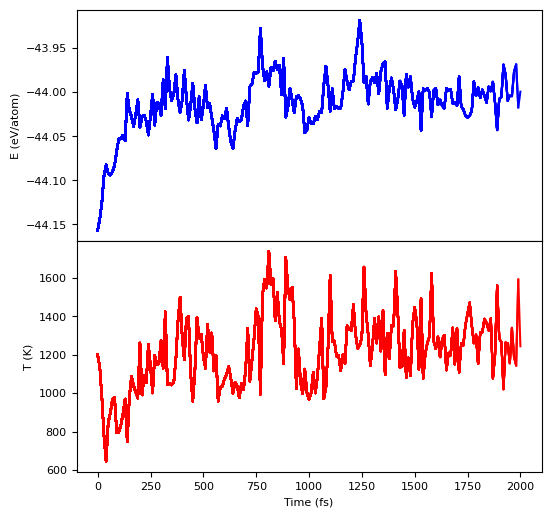

MD finished in 0.86 minutes!


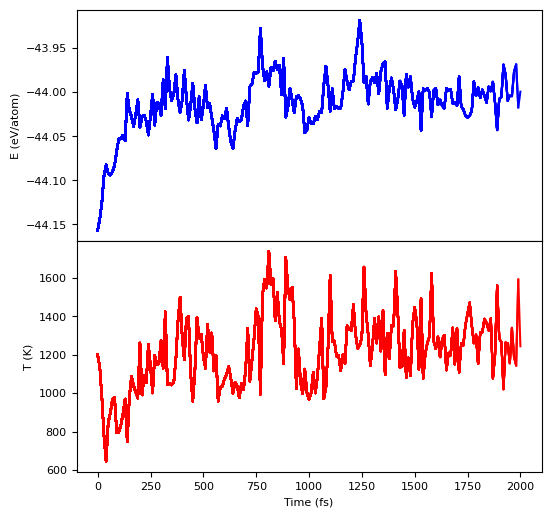

In [187]:
# reinitialize the original config
 #let us start with a single molecule
md_config=init_conf.copy()


from tblite.ase import TBLite
xtb_calc = TBLite(method="GFN2-xTB",verbosity=0)

### running this can take a long time, try for yourself. we will provide the pregenerated trajectory
simpleMD(md_config, temp=temperature, calc=xtb_calc, 
         fname='moldyn/xtb/xtb_md_both.xyz', s=10, T=2000,
         friction=0.1, seed=701, set_temperature=False)

In [189]:
from ase.io import read, write

traj = read('moldyn/xtb/xtb_md_both.xyz', ':')

viewert = WeasWidget()
viewert.from_ase(traj)
viewert.avr.model_style = 0
viewert.avr.show_hydrogen_bonds = False
viewert

WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x77e6965adf10>,))

And again lets compare some properties obtained from dynamics:

In [2]:
from matplotlib import pyplot as plt
from aseMolec import anaAtoms as aa

tag = 'CN_inter' #example inputs: 'HH_intra', 'HC_intra', 'CO_intra', 'CC_inter

for f in ['xtb/xtb_md_both.xyz', 
          f'{model_name}/mace_md_both.xyz']:
    traj = read(f'moldyn/{f}', '50:') #ignore first 50 frames
    for at in traj:
        at.pbc = True #create a fake box for rdf compatibility
        at.cell = [100,100,100]
    rdf = aa.compute_rdfs_traj_avg(traj, rmax=5, nbins=50) #aseMolec provides functionality to compute RDFs
    plt.plot(rdf[1], rdf[0][tag], '.-', label=f, alpha=0.7, linewidth=3)

plt.legend();
plt.yticks([]);
plt.xlabel(r'R ($\rm \AA$)');
plt.ylabel('RDF '+tag);

NameError: name 'model_name' is not defined

**Task for you**

<div class="alert alert-block alert-info">

- How do the xtb dynamics compare?
</div>


## 5. Training a MACE model on both molecules

From section 4 you may have noticed some issues with the MACE potential. This largely stems from the fact we have ventured out of domain for our potential. The next tutorial will cover strategies to avoid this, but for now lets train a new MACE model on a dataset that does contain both models

In [253]:
from ase.io import read, write
from weas_widget import WeasWidget

import numpy as np

db = read('data/cat_eth_caf_expanded_data.xyz', ':') #read in list of configs

print("Number of configs in database: ", len(db))
print("Number of atoms in each config: ", np.array([len(at) for at in db]))
print("Number of atoms in the smallest config: ", np.min([len(at) for at in db])) #test if database contains isolated atoms
print("Information stored in config.info: \n", db[10].info) #check info
print("Information stored in config.arrays: \n", db[10].arrays)

Number of configs in database:  5705
Number of atoms in each config:  [9 9 9 ... 9 9 9]
Number of atoms in the smallest config:  9
Information stored in config.info: 
 {'config_type': 'ethanol', 'temperature': 300.0, 'energy_xtb': -309.66786057491134}
Information stored in config.arrays: 
 {'numbers': array([6, 6, 8, 1, 1, 1, 1, 1, 1]), 'positions': array([[-0.81006258, -0.27399018,  0.05718773],
       [ 0.50009174, -0.185209  , -0.75126516],
       [ 1.43038051,  0.66625457, -0.06004699],
       [-1.35749648, -1.08705687, -0.28310389],
       [-1.37580856,  0.58634412, -0.13611705],
       [-0.80168545, -0.42549472,  1.10962145],
       [ 0.4114879 ,  0.1311728 , -1.76809652],
       [ 0.93642831, -1.15360932, -0.87854195],
       [ 1.19231401,  1.59789492, -0.27218734]]), 'forces_xtb': array([[ 0.7435585 ,  0.18081631, -0.88592054],
       [ 0.40609628,  0.45047742,  1.76830531],
       [-0.32580025,  0.36859699, -0.78301032],
       [-1.07987969, -1.59549194, -1.01613114],
       [

'Nmol = 6 #show distribution of compositions for cluster size 6\nplt.pie(comp_dict[Nmol].values(),\n        labels=comp_dict[Nmol].keys(),\n        explode=10/(25+np.array(list(comp_dict[Nmol].values()))),\n        rotatelabels =True);'

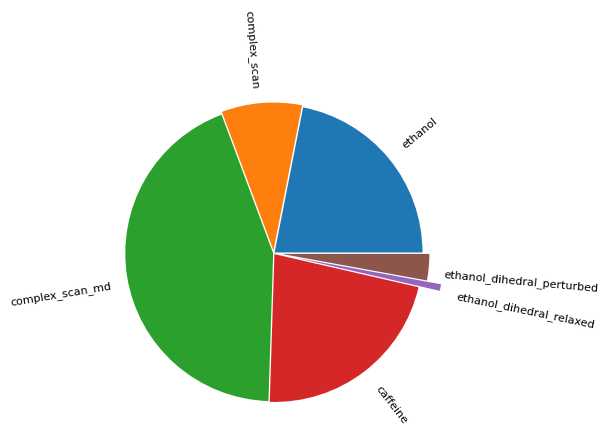

In [254]:
from aseMolec import extAtoms as ea
from collections import Counter
import matplotlib.pyplot as plt

num_confs=Counter([at.info['config_type'] for at in db]) #count number of configs for each chemical formula
plt.pie(num_confs.values(),
        labels=num_confs.keys(),
        explode=10/(25+np.array(list(num_confs.values()))),
        rotatelabels =True);
"""Nmol = 6 #show distribution of compositions for cluster size 6
plt.pie(comp_dict[Nmol].values(),
        labels=comp_dict[Nmol].keys(),
        explode=10/(25+np.array(list(comp_dict[Nmol].values()))),
        rotatelabels =True);"""

**Task for you**

<div class="alert alert-block alert-info">

- Make a training and validation dataset like we did before. Here are a few pointers:
- It is probably a good idea to give a different name as before. 
- It's up to you how many configs we put in the train/validation set, but consider we have a larger configuration space we want to cover.
- Remember to add the E0s to the train dataset! (we can use the ones we caclulated before)
</div>


In [ ]:
from ase.io import read, write
import numpy as np


#Load the data
db = read('data/cat_eth_caf_expanded_data.xyz', ':')
isolated_atoms= read('data/HCNO_E0s.xyz', ':')
len_data=len(db)
print(f"Number of configs in database: {len_data}")

#Set fraction of database we want to use for training, the rest will be used for validation
train_number=500
valid_number=500
print(f"Number of configs for training: {train_number}")
print(f"Number of configs for validation: {valid_number}")
if train_number+valid_number>len_data:
    raise ValueError(f"train_number + valid_number = {train_number+valid_number} exceeds the number of configs in the database: {len_data}")

#Randomly shuffle the database
np.random.seed(42)
np.random.shuffle(db)

write(f'data/cat_eth_caf_expanded_xtb_train_{train_number}.xyz', db[:train_number]+isolated_atoms) #first train_number configs
write(f'data/cat_eth_caf_expanded_xtb_validation_{valid_number}.xyz', db[-valid_number:]) #last valid_number configs for validation

Number of configs in database: 5705
Number of configs for training: 1500
Number of configs for validation: 500


Now we can train another model. Make sure to check the log to see everything is as expected!

In [300]:
import yaml
from pathlib import Path
model_name = f"mace02_{train_number}_{valid_number}"

config = {
    "model": "MACE",
    "num_interactions": 2,
    "num_channels": 32,
    "max_L": 0,
    "correlation": 2,
    "r_max": 5.0,
    "max_ell": 2,
    "name": f"{model_name}",
    "model_dir": f"MACE_models/{model_name}",
    "log_dir": f"MACE_models/{model_name}/logs/",
    "checkpoints_dir": f"MACE_models/{model_name}/checkpoints/",
    "results_dir": f"MACE_models/{model_name}/results/",
    "train_file": f"data/cat_eth_caf_expanded_xtb_train_{train_number}.xyz",
    "valid_file": f"data/cat_eth_caf_expanded_xtb_validation_{valid_number}.xyz",
    "test_file": f"data/cat_eth_caf_expanded_xtb_validation_{valid_number}.xyz",
    "energy_key": "energy_xtb",
    "forces_key": "forces_xtb",
    "batch_size": 10,
    "max_num_epochs": 100,
    "swa": True,
    "swa_lr": 0.001,
    "seed": 123,
}

Path("config/config-03.yml").write_text(yaml.safe_dump(config, sort_keys=False))


600

In [298]:
dev = f'device: {device}'
%store dev >>"config/config-03.yml"

Writing 'dev' (str) to file 'config/config-03.yml'.


In [ ]:


!mace_run_train --config config/config-03.yml
# if you run on cpu pass --device=cpu to the command above

#remove checkpoints since they may cause errors on retraining a model with the same name but a different architecture

p = Path(f"MACE_models/{model_name}/")

_ = [file.unlink() for file in p.glob("*_run-*.model")]
_ = [file.unlink() for file in p.glob("*.pt")]


/home/ijp30/mace-env/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/ijp30/mace-env/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/ijp30/mace-env/lib/python3.12/site-packages/torch/jit/_script.py:1480: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
2026-07-24 18:01:42.059 INFO: ===========VERIFYING SETTINGS===========
2026-07-24 18:01:42.059 INFO: MACE version: 0.3

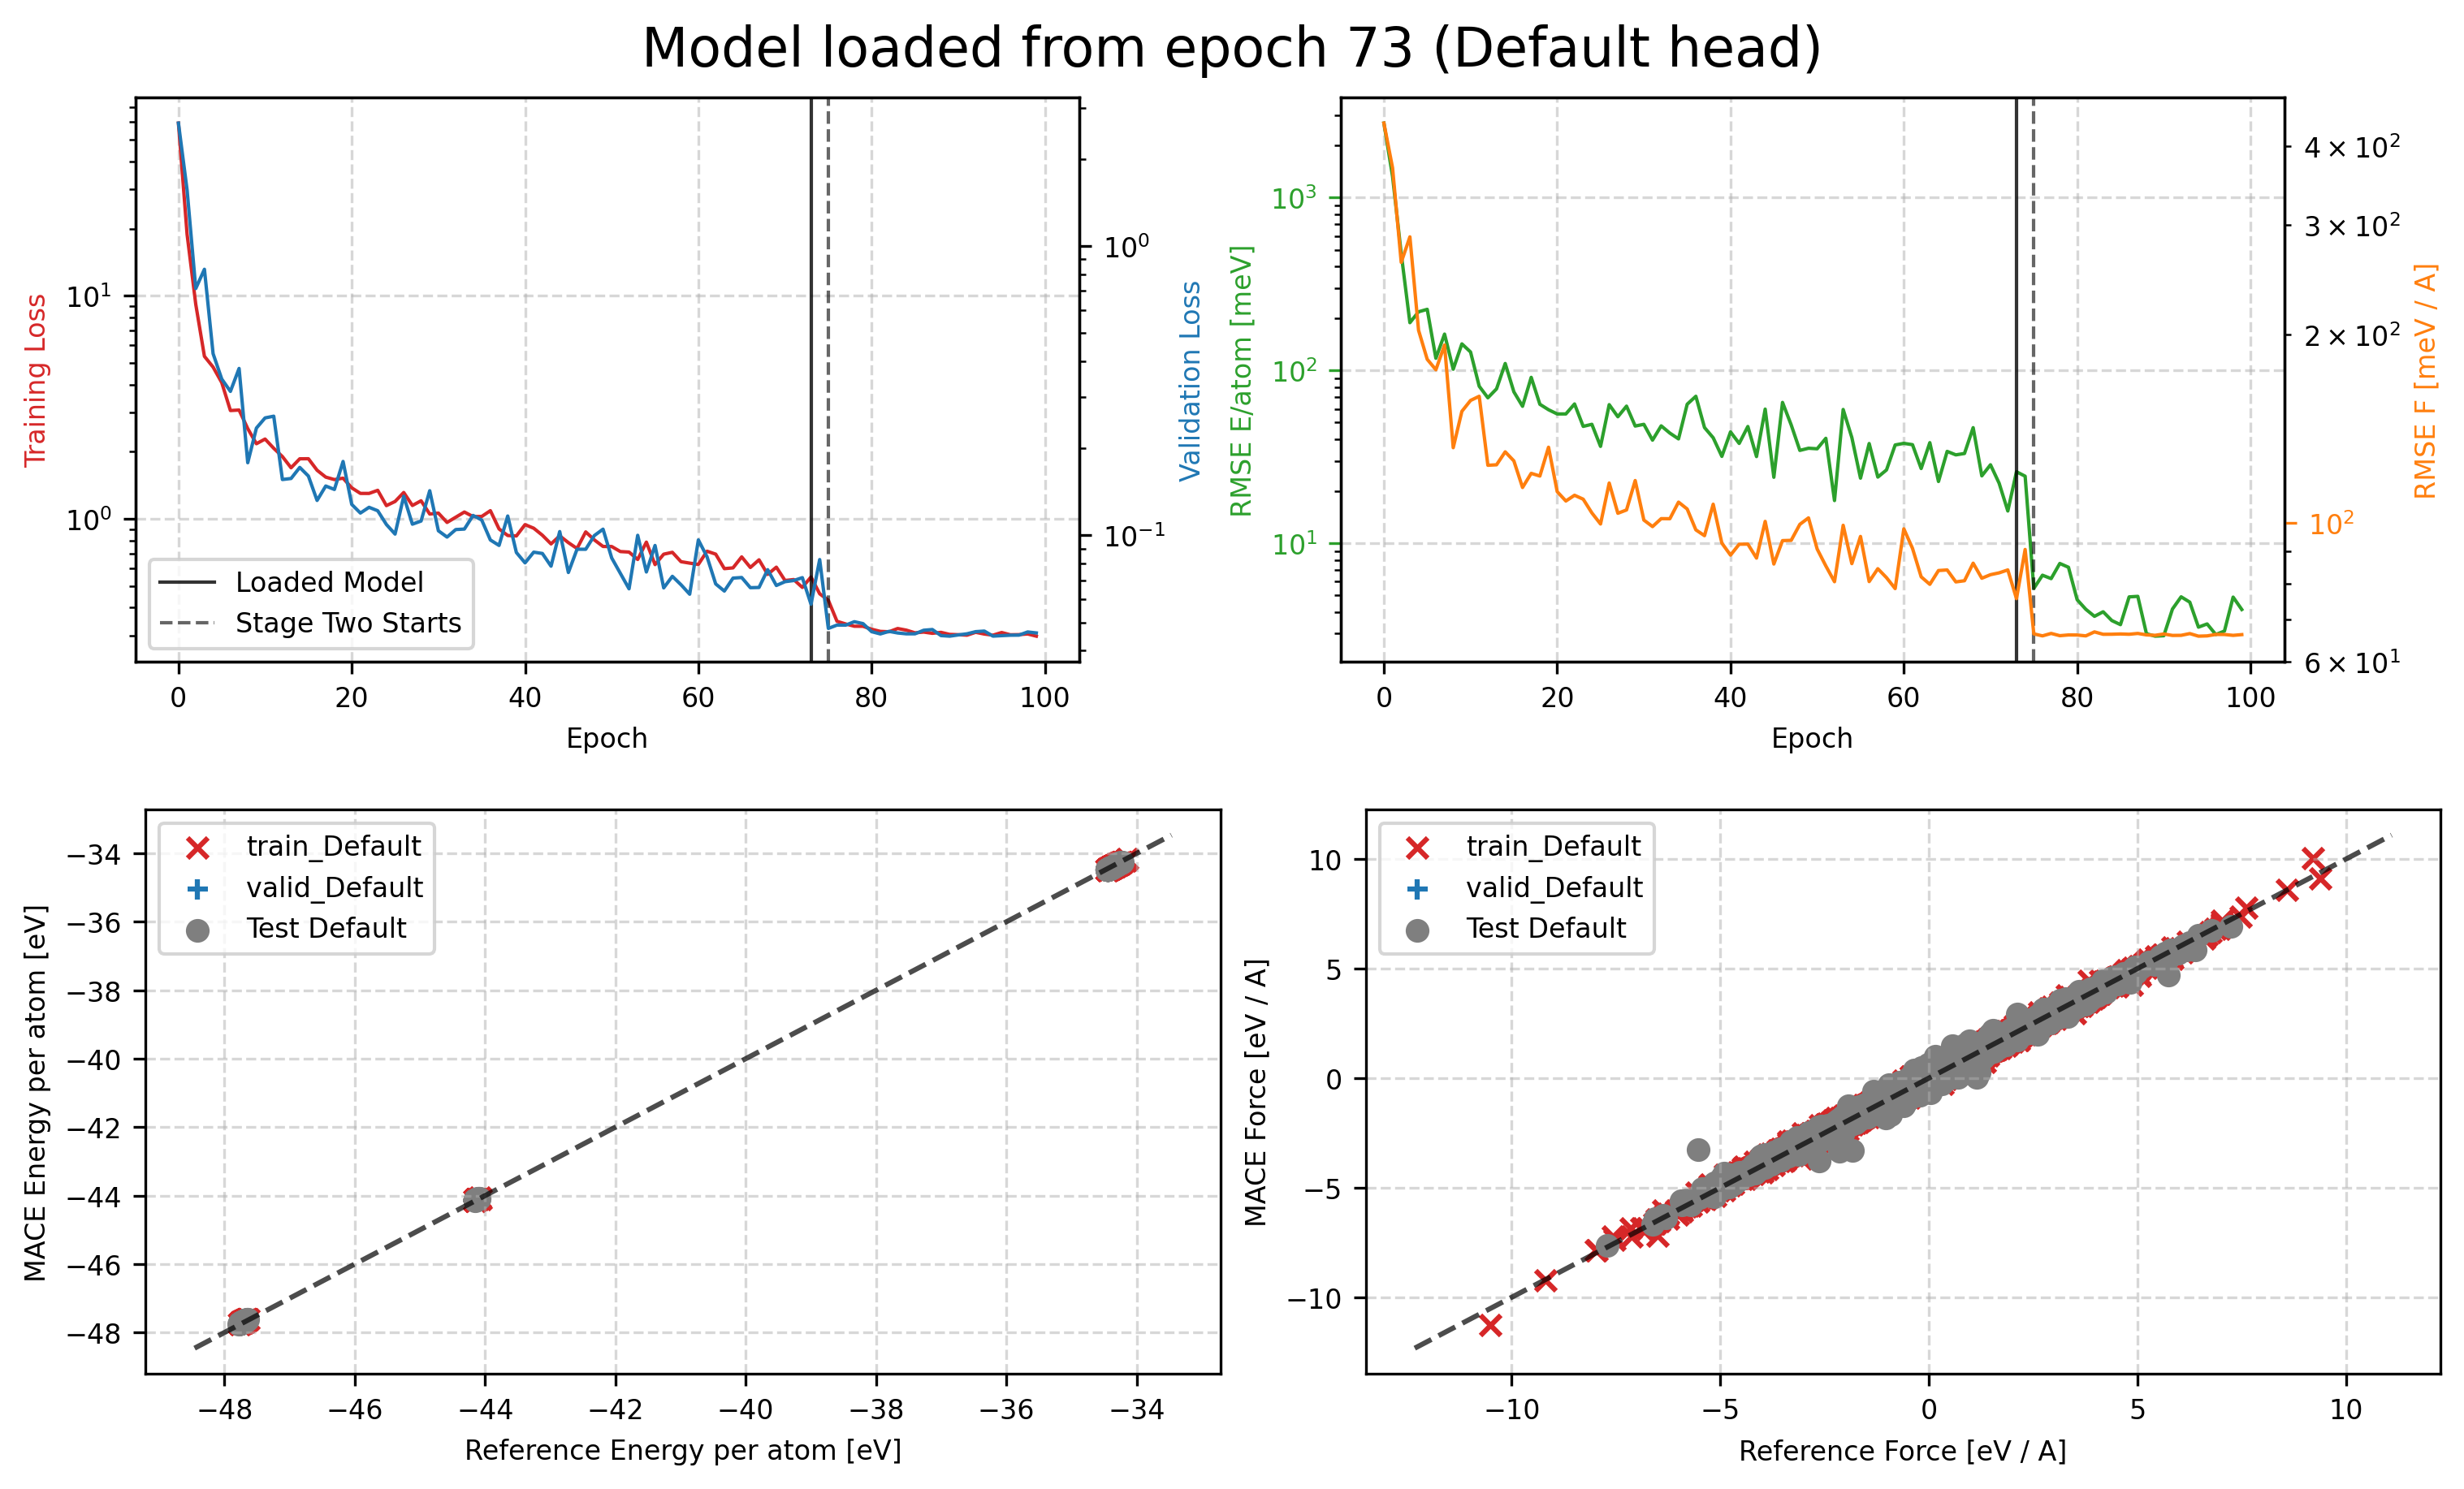

In [200]:
from IPython.display import Image, display
display(Image(f"MACE_models/{model_name}/results/{model_name}_run-123_train_Default_stage_one.png"))

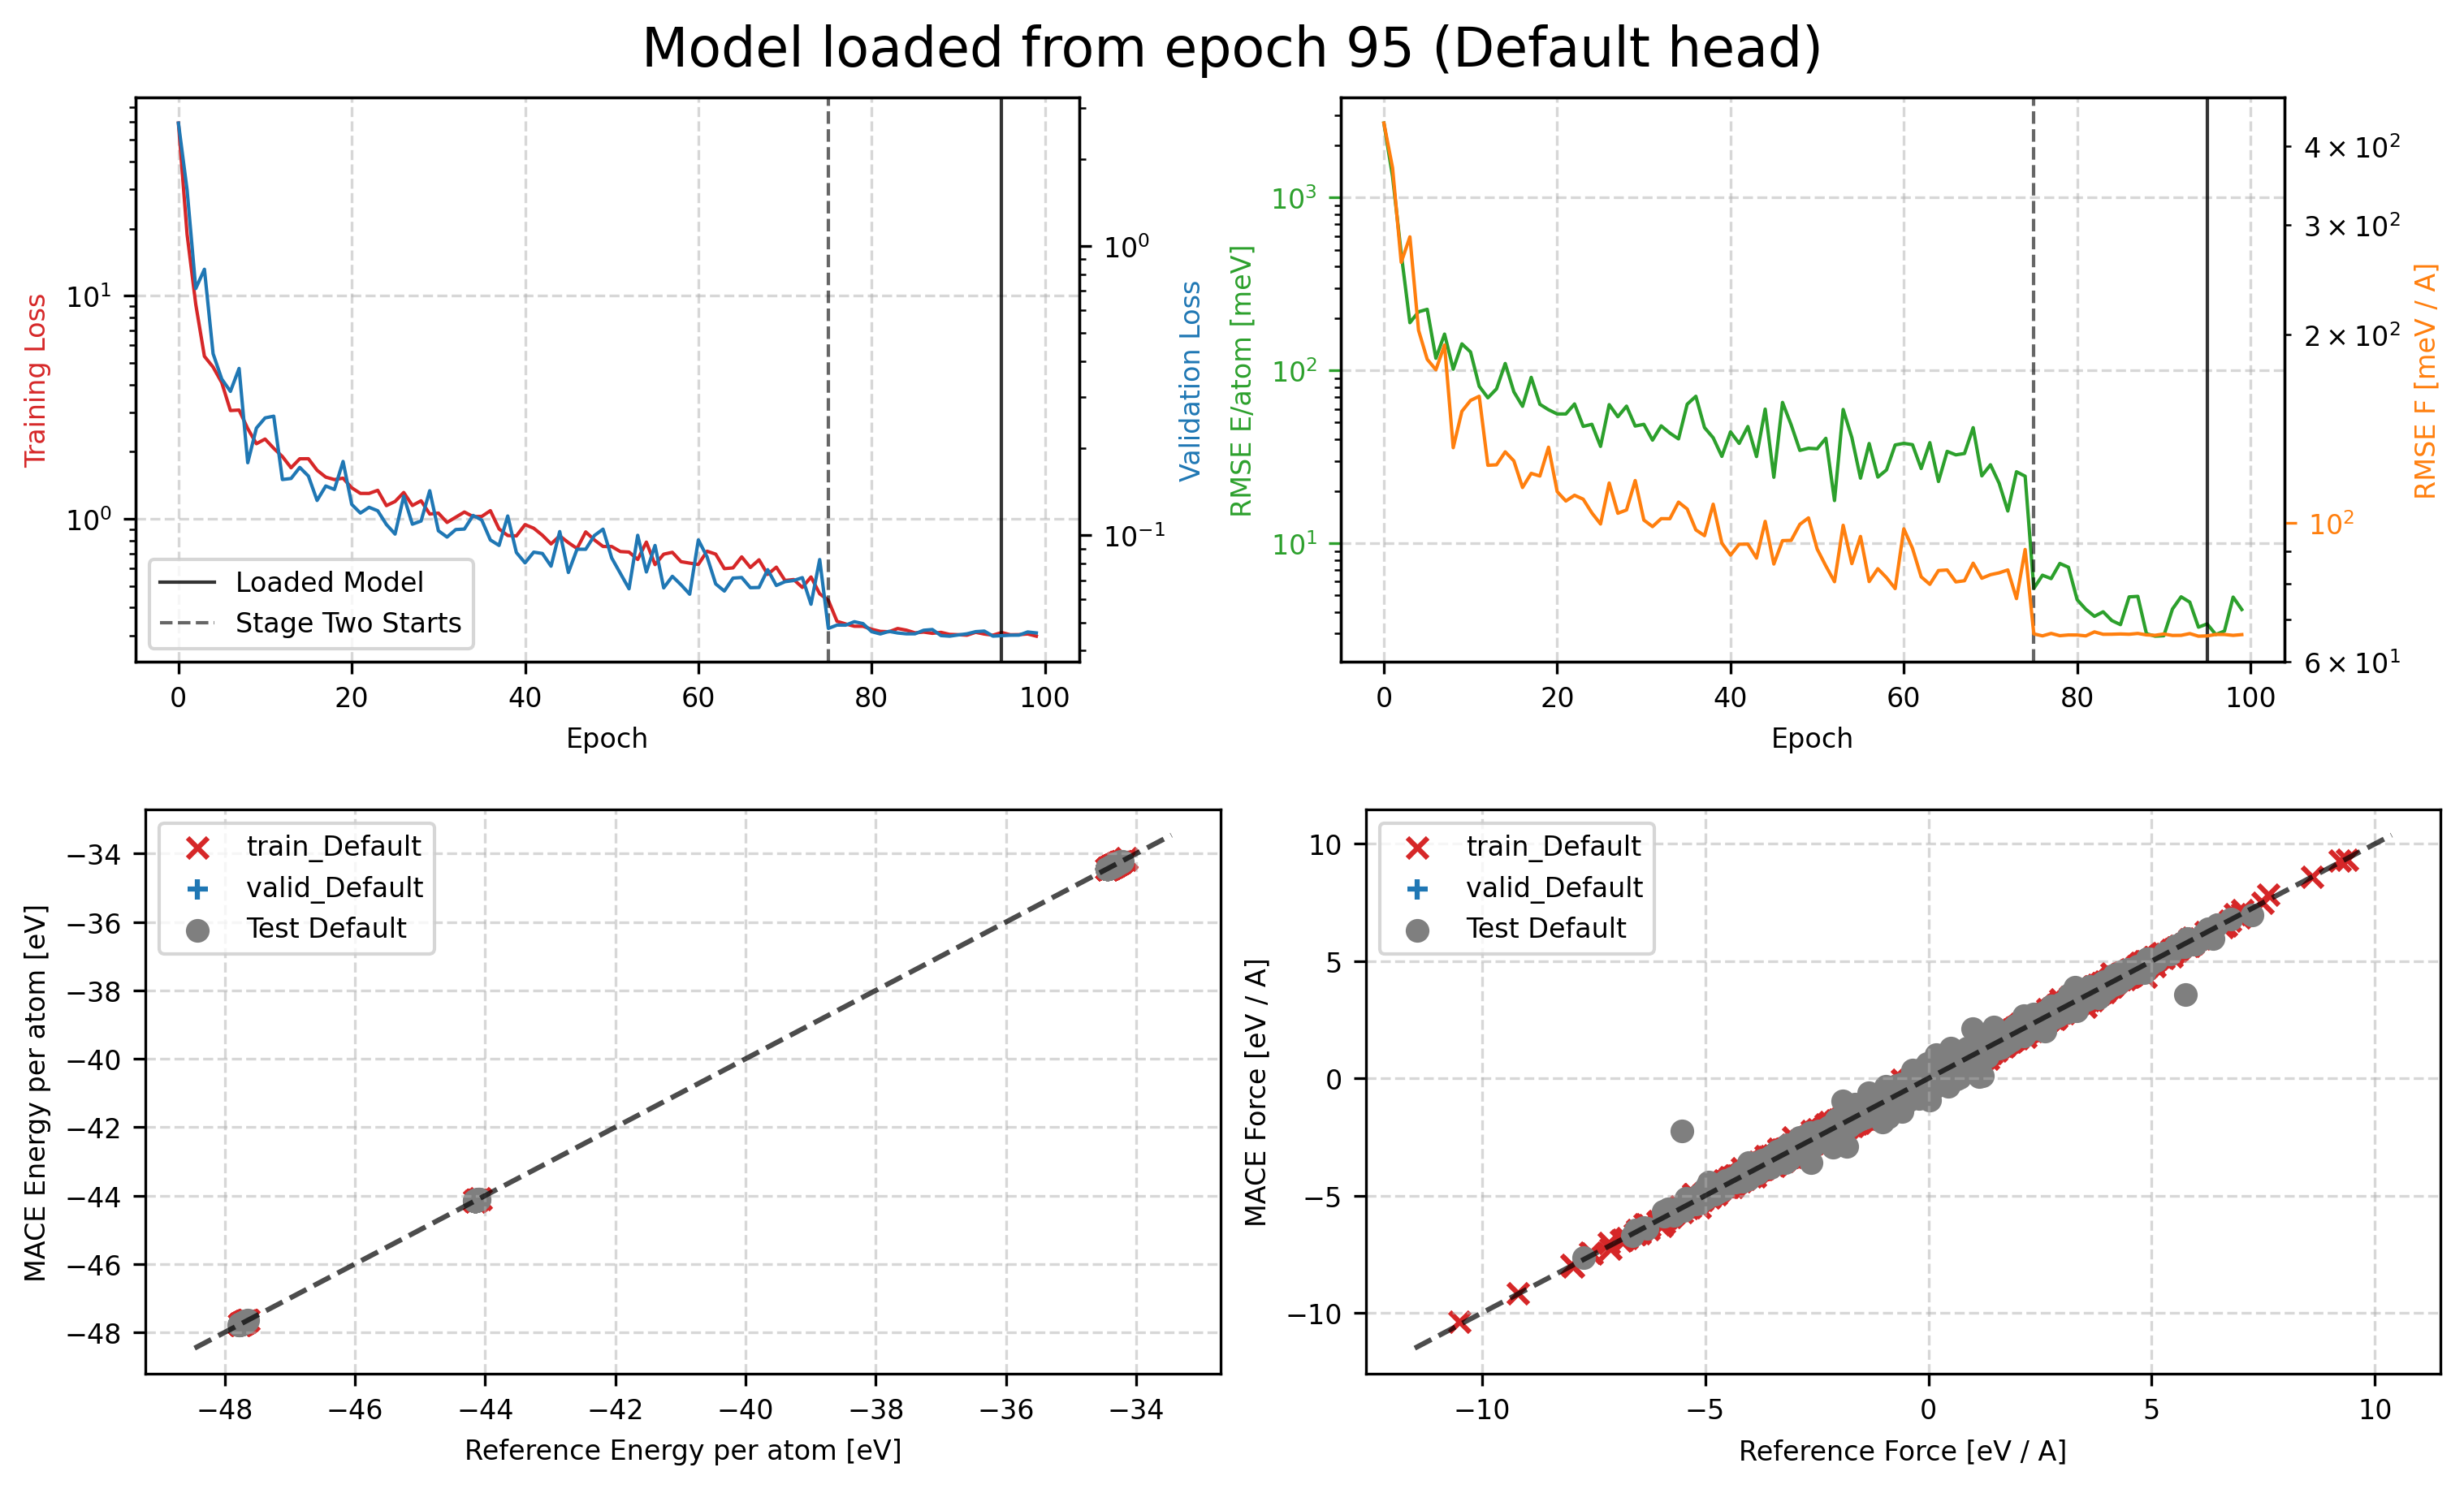

In [201]:
from IPython.display import Image, display
display(Image(f"MACE_models/{model_name}/results/{model_name}_run-123_train_Default_stage_two.png"))

In [ ]:
import warnings
warnings.filterwarnings("ignore")

Path("tests/mace02/").mkdir(parents=True, exist_ok=True)

#Note you will have to replace the {} with the actual variable values yourself

#evaluate the train set
!mace_eval_configs \
    --configs="data/cat_eth_caf_expanded_xtb_train_{train_number}.xyz" \
    --model="MACE_models/{model_name}/{model_name}_run-123_train_stage_two.model" \
    --output="MACE_models/{model_name}/{model_name}_run-123_train_stage_two_eval_train.xyz"

#evaluate the test set
!mace_eval_configs \
    --configs="data/cat_eth_caf_expanded_xtb_validation_{valid_number}.xyz" \
    --model="MACE_models/{model_name}/{model_name}_run-123_train_stage_two.model" \
    --output="MACE_models/{model_name}/{model_name}_run-123_train_stage_two_eval_validation.xyz"

/home/ijp30/mace-env/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/ijp30/mace-env/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/ijp30/mace-env/lib/python3.12/site-packages/torch/jit/_script.py:1480: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/home/ijp30/mace-env/lib/python3.12/site-packages/mace/cli/eval_configs.py:140: UserWarning: Environment variable TORC

Lets now run some dynamics again!

In [222]:
from mace.calculators import MACECalculator
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
# change to device='cpu' if you run on cpu
device='cuda'
temperature=1200

init_conf = read('data/caffeine_ethanol_scan_xtb.xyz', 0) 

#Initialise with vel that move molecules towards each other
ethanol_pos=init_conf.positions[-9:]
ethanol_masses=init_conf.get_masses()[-9:]
ethanol_center=ethanol_pos.mean(axis=0)

caffeine_pos=init_conf.positions[:-9]
caffeine_masses=init_conf.get_masses()[:-9]
caffeine_center=caffeine_pos.mean(axis=0)

MaxwellBoltzmannDistribution(init_conf, temperature_K=temperature) #initialize temperature at 300

#Initialize velocities to move the molecules towards each other
delta = caffeine_center-ethanol_center
ethanol_velocities = delta  # Scale the velocity for a gentle approach
caffeine_velocities = -delta  # Opposite direction for caffeine


init_conf.arrays['momenta'][:-9] = caffeine_velocities * caffeine_masses[:, np.newaxis] 
init_conf.arrays['momenta'][-9:] = ethanol_velocities * ethanol_masses[:, np.newaxis]

#Scale velocities to match the desired temperature
current_temperature = init_conf.get_temperature()
scaling_factor = np.sqrt(temperature / current_temperature)
init_conf.arrays['momenta'] *= scaling_factor


print("Initial configuration: \n", init_conf)
#get temperature of the system
print("Initial temperature: \n", init_conf.get_temperature())


Initial configuration: 
 Atoms(symbols='CNCNC3ONCONC2H10C2OH6', pbc=False, cell=[20.0, 20.0, 20.0], forces_xtb=..., molID=..., momenta=...)
Initial temperature: 
 1200.0000000000007


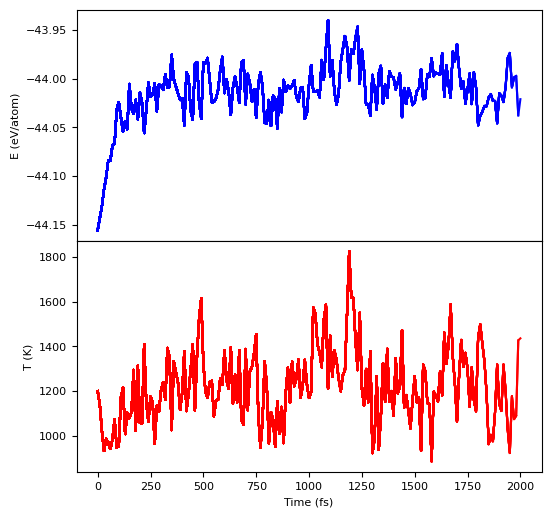

MD finished in 0.88 minutes!


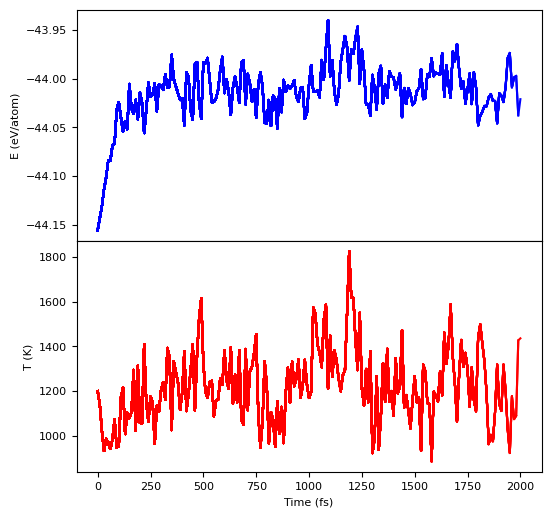

In [223]:
### running this can take a long time, try for yourself. we will provide the pregenerated trajectory
md_config=init_conf.copy()

Path(f"moldyn/{model_name}").mkdir(parents=True, exist_ok=True)

mace_calc = MACECalculator(model_paths=[f'MACE_models/{model_name}/{model_name}_stagetwo_compiled.model'], 
                           device=device, 
                           default_dtype="float32")

simpleMD(md_config, temp=temperature, calc=mace_calc, 
         fname=f'moldyn/{model_name}/mace_md_both.xyz', s=10, T=2000,
         friction=0.1, seed=701, set_temperature=False)

In [217]:
from ase.io import read, write
from weas_widget import WeasWidget

traj = read(f'moldyn/{model_name}/mace_md_both.xyz', ':')

viewert = WeasWidget()
viewert.from_ase(traj)
viewert.avr.model_style = 0
viewert.avr.show_hydrogen_bonds = False
viewert

WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x77e61f6f7890>,))

100%|██████████| 50/50 [00:01<00:00, 45.70it/s]


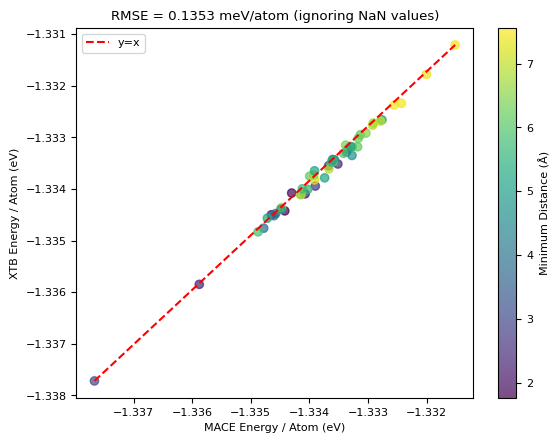

In [224]:
from ase.io import read, write
from aseMolec import extAtoms as ea
import matplotlib.pyplot as plt
from tqdm import tqdm

sampled_mace_traj = read(f'moldyn/{model_name}/mace_md_both.xyz', '1::4')
xtb_calc = TBLite(method="GFN2-xTB",verbosity=0)


min_distances=[]

Natoms=len(sampled_mace_traj[0])
idx=0
for at in tqdm(sampled_mace_traj):
    min_distance=1000
    at.calc = xtb_calc
    try:
        at.info['energy_xtb'] = at.get_potential_energy()
        at.arrays['forces_xtb'] = at.get_forces()
    except Exception as e:
        print(f"Error calculating energy and forces for configuration {idx}: {e}")
        at.info['energy_xtb'] = np.nan
        at.arrays['forces_xtb'] = np.full_like(at.positions, np.nan)
    ethanol_positions=at.positions[-9:]
    ethanol_center=ethanol_positions.mean(axis=0)

    #We will color by min distance between atoms between 2 molecules
    #Is there any correlation?
    for pos in ethanol_positions:
        delta_eth_caff = pos - at.positions[:-9]
        distances = np.linalg.norm(delta_eth_caff, axis=1)
        min_distance = np.min([np.min(distances),min_distance])
    min_distances.append(min_distance)
    idx+=1

mace_energies = ea.get_prop(sampled_mace_traj, 'info', 'md_energy', True).flatten()
xtb_energies = ea.get_prop(sampled_mace_traj, 'info', 'energy_xtb', True).flatten()
#calculate RMSE for energies, ingnoring NaN values
valid_indices = ~np.isnan(xtb_energies)
rmse_energy = np.sqrt(np.mean((mace_energies[valid_indices]-xtb_energies[valid_indices])**2))

plt.scatter(mace_energies  / Natoms, xtb_energies  / Natoms, c=min_distances, cmap='viridis', alpha=0.7)
plt.xlabel('MACE Energy / Atom (eV)')
plt.ylabel('XTB Energy / Atom (eV)')
plt.plot([min(mace_energies / Natoms), max(mace_energies / Natoms)], 
          [min(xtb_energies / Natoms), max(xtb_energies / Natoms)], 'r--', label='y=x')
cbar = plt.colorbar()
cbar.set_label('Minimum Distance (Å)')
plt.title(f'RMSE = {1000*rmse_energy/Natoms:.4f} meV/atom (ignoring NaN values)')
plt.legend()
plt.show()

You should hopefully see better correlation between XTB and MACE

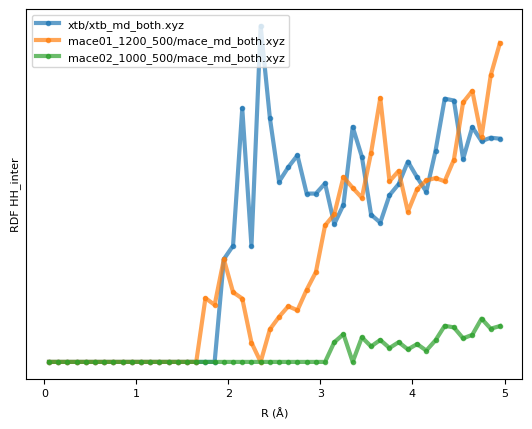

In [252]:
from matplotlib import pyplot as plt
from aseMolec import anaAtoms as aa

tag = 'HH_inter' #example inputs: 'HH_intra', 'HC_intra', 'CO_intra', 'CC_inter

for f in ['xtb/xtb_md_both.xyz', 
          'mace01_1200_500/mace_md_both.xyz',
          f'{model_name}/mace_md_both.xyz',
          ]:
    traj = read(f'moldyn/{f}', '50:') #ignore first 50 frames
    for at in traj:
        at.pbc = True #create a fake box for rdf compatibility
        at.cell = [100,100,100]
    rdf = aa.compute_rdfs_traj_avg(traj, rmax=5, nbins=50) #aseMolec provides functionality to compute RDFs
    plt.plot(rdf[1], rdf[0][tag], '.-', label=f, alpha=0.7, linewidth=3)

plt.legend();
plt.yticks([]);
plt.xlabel(r'R ($\rm \AA$)');
plt.ylabel('RDF '+tag);

We can also look at how the energy changes as we move the 2 molecules changes, which measures how well our model is capturing intermolecular interactions:

In [ ]:
init_conf = read('data/caffeine_ethanol_scan_xtb.xyz', 0)

distance_range=[0, 8]


distance_arr=np.linspace(distance_range[0], distance_range[1], 50)
traj=[]
#Translate the molecules so the min distance between atoms in each molecule is equal to the distance in distance_arr
for d in distance_arr:
    atoms=init_conf.copy()
    ethanol_pos=atoms.positions[-9:]
    caffeine_pos=atoms.positions[:-9]

    #Calculate the current min distance between atoms in each molecule
    min_distance=1000
    for pos in ethanol_pos:
        delta_eth_caff = pos - caffeine_pos
        scalar_distances = np.linalg.norm(delta_eth_caff, axis=1)
        translation_vector_index=np.argmin(scalar_distances)
        translation_vector=delta_eth_caff[translation_vector_index]
        if np.linalg.norm(translation_vector)<min_distance:
            min_distance=np.linalg.norm(translation_vector)
            translation_vector=translation_vector
        

    #Calculate the translation vector to move the ethanol molecule
    translation_vector_scale=(d-min_distance)/np.linalg.norm(translation_vector)
    translation_vector=translation_vector*translation_vector_scale
    atoms.positions[-9:] += translation_vector
    traj.append(atoms)
    #calculate the min distance between atoms in each molecule after translation
    ethanol_pos=atoms.positions[-9:]
    caffeine_pos=atoms.positions[:-9]
    min_distance=1000


    

In [294]:
from weas_widget import WeasWidget

viewert = WeasWidget()
viewert.from_ase(traj)
viewert.avr.model_style = 0
viewert.avr.show_hydrogen_bonds = False
viewert

WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x77e6a5281880>,))

100%|██████████| 50/50 [00:33<00:00,  1.51it/s]


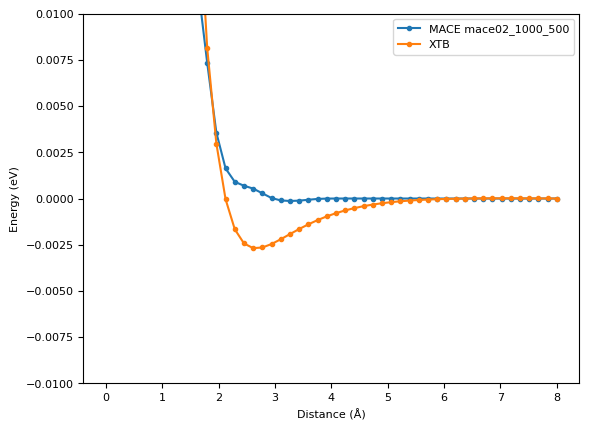

In [295]:

calc=MACECalculator(model_paths=[f'MACE_models/{model_name}/{model_name}_stagetwo_compiled.model'], 
                    device=device, 
                    default_dtype="float32")
xtb_calc = TBLite(method="GFN2-xTB",verbosity=0)
for at in tqdm(traj):
    at.calc = calc
    at.info['energy_mace'] = at.get_potential_energy()
    at.arrays['forces_mace'] = at.get_forces()
    xtb_calc = TBLite(method="GFN2-xTB",verbosity=0)
    at.calc = xtb_calc
    at.info['energy_xtb'] = at.get_potential_energy()
    at.arrays['forces_xtb'] = at.get_forces()
mace_energies = ea.get_prop(traj, 'info', 'energy_mace', True).flatten()
xtb_energies = ea.get_prop(traj, 'info', 'energy_xtb', True).flatten()
plt.plot(distance_arr, mace_energies-mace_energies[-1], '.-', label=f'MACE {model_name}')
plt.plot(distance_arr, xtb_energies-xtb_energies[-1], '.-', label=f'XTB')
plt.xlabel('Distance (Å)')
plt.ylabel('Energy (eV)')
plt.ylim(-0.01,0.01)
plt.legend()

**Task for you**

<div class="alert alert-block alert-info">

- Try some other starting configurations
- Think about why these two curves are different. How might this change with model hyperparameters and a different dataset.
</div>


## 6 Running on the condensed phase

Up to now we have only run md in the gas phase - what about the condensed phase? We have no data of this kind in our dataset, so this very much extrapolative

In [237]:
from mace.calculators import MACECalculator
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
# change to device='cpu' if you run on cpu
device='cuda'
temperature=400

init_conf = read('data/caffeine_ethanol_scan_xtb.xyz', 0) 
init_conf.cell=[7.5,7.5,7.5]
init_conf.pbc=True

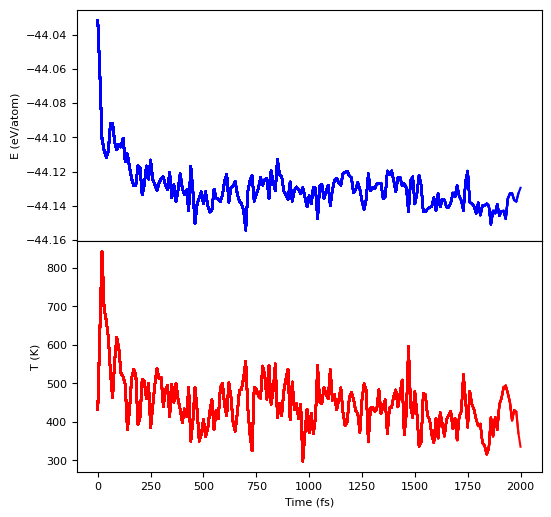

MD finished in 1.00 minutes!


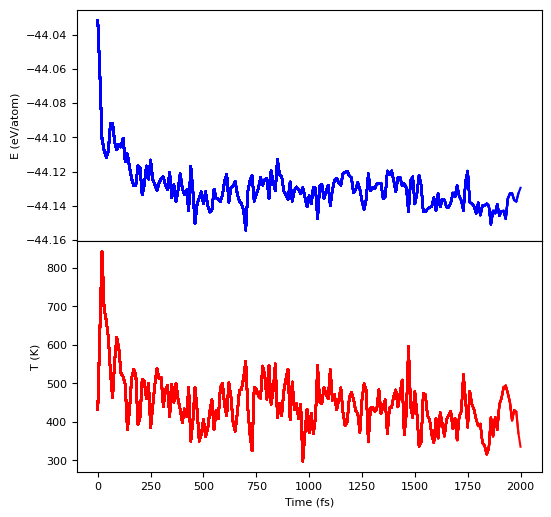

In [239]:
### running this can take a long time, try for yourself. we will provide the pregenerated trajectory
md_config=init_conf.copy()

from ase.io import read, write
Path(f"moldyn/{model_name}/").mkdir(parents=True, exist_ok=True)
write(f'moldyn/{model_name}/mace_md_condensed_init.xyz',
      init_conf) #save initial configuration

mace_calc = MACECalculator(model_paths=[f'MACE_models/{model_name}/{model_name}_stagetwo_compiled.model'], 
                           device=device, 
                           default_dtype="float32")

simpleMD(md_config, temp=temperature, calc=mace_calc, 
         fname=f'moldyn/{model_name}/mace_md_condensed.xyz', s=10, T=2000,
         friction=0.1, seed=701, set_temperature=True)

In [241]:
from ase.io import read, write
from weas_widget import WeasWidget

traj = read(f'moldyn/{model_name}/mace_md_condensed.xyz', ':')

viewert = WeasWidget()
viewert.from_ase(traj)
viewert.avr.model_style = 0
viewert.avr.show_hydrogen_bonds = False
viewert

WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x77e68e39df10>,))

And for XTB.

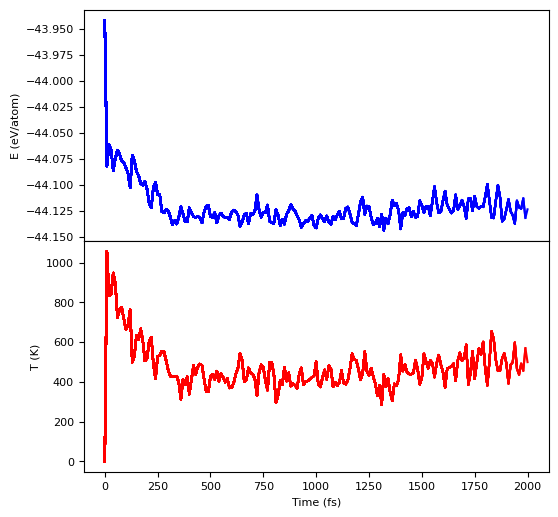

MD finished in 6.77 minutes!


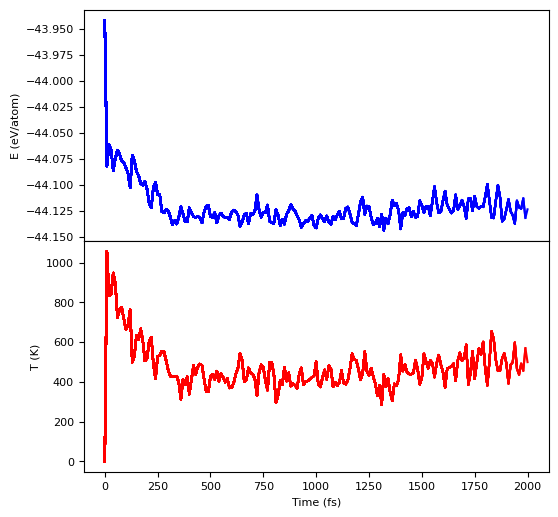

In [242]:
# reinitialize the original config
 #let us start with a single molecule
md_config=init_conf.copy()


from tblite.ase import TBLite
xtb_calc = TBLite(method="GFN2-xTB",verbosity=0)

### running this can take a long time, try for yourself. we will provide the pregenerated trajectory
simpleMD(md_config, temp=temperature, calc=xtb_calc, 
         fname='moldyn/xtb/xtb_md_condensed.xyz', s=10, T=2000,
         friction=0.1, seed=701, set_temperature=False)

 You may find it runs much slower this time round. This is a situation where we can see the speed of MLIPs can allow us to do more science.

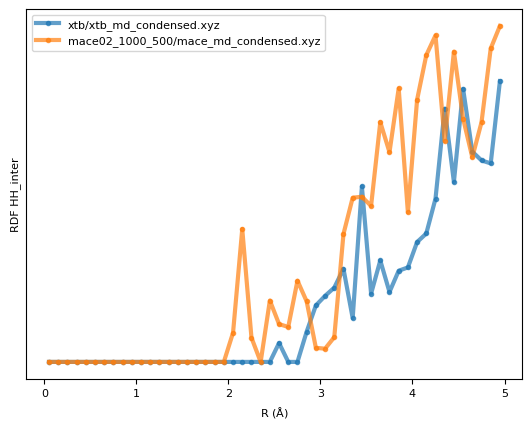

In [ ]:
from matplotlib import pyplot as plt
from aseMolec import anaAtoms as aa

tag = 'HH_inter' #example inputs: 'HH_intra', 'HC_intra', 'CO_intra', 'CC_inter

for f in ['xtb/xtb_md_condensed.xyz', 
          f'{model_name}/mace_md_condensed.xyz',
          ]:
    traj = read(f'moldyn/{f}', '50:') #ignore first 50 frames
    for at in traj:
        at.pbc = True #create a fake box for rdf compatibility
        at.cell = [100,100,100]
    rdf = aa.compute_rdfs_traj_avg(traj, rmax=5, nbins=50) #aseMolec provides functionality to compute RDFs
    plt.plot(rdf[1], rdf[0][tag], '.-', label=f, alpha=0.7, linewidth=3)

plt.legend();
plt.yticks([]);
plt.xlabel(r'R ($\rm \AA$)');
plt.ylabel('RDF '+tag);

Transferability from clusters to the condensed phase environment is still an [open research](https://doi.org/10.1021/acs.jctc.5c02043) question. If this works, it implies that we might be able to learn highly accurate Quantum Chemistry PES on molecular clusters and make predictions (density, diffusivity) for the condensed phase!

## 7 Diving deeper

At this point, or after the lecture deep diving into MACE, you may want to go through the notebook again and try changing some of the other model internals or other training parameters to see how this changes the performance of MACE.

**Task for you**

<div class="alert alert-block alert-info">

- Try changing the model size: (`r_max`, `num_interactions`, `num_channels`, `max_L`, `correlation`)? Which of these makes the biggest difference? How does the molecular seperation curve change at the end of section 5? Notice the accuracy vs speed trade-off.
- You could try automating this task - perform a hyperparameter sweep.
- Monitor the memory and usage of your GPU using `nvitop` in the `terminal`. What changes when increasing the `batch_size`?

</div>